<a href="https://colab.research.google.com/github/NatP-dev/Complete-Python-3-Bootcamp/blob/master/Welcome_to_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning for Cryptocurrency Portfolio Optimization**

## **Author**: Nathalia Pouroullis
## **Student Number**: 18050
## **Date**: 30 March 2025

# 1. Introduction  
Cryptocurrency markets are highly volatile, with non-stationary behavior and complex correlation structures.  
Traditional portfolio optimization techniques, such as **Modern Portfolio Theory (MPT)**, often fail to capture the **non-linear dependencies** and **extreme price fluctuations** seen in digital assets.  

This project evaluates whether **machine learning-driven portfolio optimization techniques** can outperform traditional methods in the cryptocurrency domain.  

## **Objective**  
The primary goal of this study is to develop an ML-based approach for **portfolio allocation** and compare its performance against traditional mean-variance optimization methods.  
We focus on evaluating risk-adjusted metrics, including the **Sharpe ratio, Sortino ratio, and maximum drawdown**.  

# **Table of Content**


# **Can Machine Learning Improve Portfolio Optimization for Cryptocurrencies?**

Cryptocurrency markets are known for their high volatility, non-stationary behavior, and complex correlation structures. Traditional portfolio optimization techniques, such as Modern Portfolio Theory (MPT), may not fully capture the non-linear dependencies and extreme price fluctuations characteristic of digital assets.

Machine learning (ML) provides an opportunity to enhance portfolio allocation strategies by leveraging historical patterns, advanced risk modeling, and adaptive decision-making frameworks. This study evaluates whether ML-driven portfolio optimization techniques can outperform traditional methods in the cryptocurrency domain.

---

## **Key Research Objectives**

- **Assessing historical data trends:** Analyzing the past five years of cryptocurrency price data.
- **Comparing portfolio strategies:** Evaluating traditional (mean-variance optimization) vs. ML-based approaches.
- **Risk-adjusted performance:** Measuring key financial metrics like the Sharpe ratio, Sortino ratio, and drawdowns.
- **Future considerations:** What else could be added to this data to enhance the model?  
<br><br>

---

<br><br>

---

## **Time-Series Analysis & Portfolio Optimization**
This study uses historical daily price data to analyze trends, volatility, and market dynamics. By incorporating machine learning, we can explore adaptive portfolio allocation techniques that outperform traditional methods.


# **0 - Imports**



In [27]:
################################ LIBRARIES ########################
# Necessary libraries
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import yfinance as yf
import re
import time
import math

# Statistical and Optimization Libraries
from scipy.stats import norm, zscore, skew, kurtosis, median_abs_deviation
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, classification_report

# Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Date Handling
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **1 - Data Import**

#### **Data Source and Reliability**
This study utilizes data from **Yahoo Finance**, a widely recognized and reliable provider of financial market data. Yahoo Finance aggregates pricing information from multiple exchanges, ensuring accuracy, consistency, and historical depth. The dataset includes adjusted closing prices and trading volumes, critical for financial modeling, volatility analysis, and portfolio optimization.
<br> <br>
#### **Time Frame and Coverage**
The dataset spans five years (March 1, 2020 – March 1, 2025), with daily observations. This period ensures coverage of bull and bear market phases, allowing for a robust evaluation of portfolio risk, asset correlations and return performance under varying conditions.
<br> <br>
#### **Cryptocurrency Selection Criteria**
The selected cryptocurrencies were chosen based on **market capitalization, liquidity, and portfolio diversification potential**. These assets represent different sectors within the cryptocurrency space, ensuring a broad risk-return profile:

- **Bitcoin (BTC):** Store of value, benchmark asset.
- **Ethereum (ETH):** Smart contract leader, high utility.
- **Binance Coin (BNB):** Exchange token with strong adoption.
- **Cardano (ADA), Polygon (MATIC), Chainlink (LINK):** Blockchain scalability and DeFi applications.
- **XRP (Ripple), Dogecoin (DOGE), Litecoin (LTC):** Alternative payment networks with market relevance.
<br> <br>
#### **Summary of Cryptocurrencies**
<table style="border: 1px solid black; border-collapse: collapse; font-size: 14px;">
    <tr style="background-color: lightgrey;">
        <th style="border: 1px solid black; padding: 5px;">Cryptocurrency</th>
        <th style="border: 1px solid black; padding: 5px;">Category</th>
        <th style="border: 1px solid black; padding: 5px;">Market Cap</th>
        <th style="border: 1px solid black; padding: 5px;">Volatility</th>
    </tr>
    <tr><td style="border: 1px solid black; padding: 5px;">Bitcoin (BTC)</td><td style="border: 1px solid black; padding: 5px;">Store of Value</td><td style="border: 1px solid black; padding: 5px;">High</td><td style="border: 1px solid black; padding: 5px;">Medium</td></tr>
    <tr><td style="border: 1px solid black; padding: 5px;">Ethereum (ETH)</td><td style="border: 1px solid black; padding: 5px;">Smart Contracts</td><td style="border: 1px solid black; padding: 5px;">High</td><td style="border: 1px solid black; padding: 5px;">Medium</td></tr>
    <tr><td style="border: 1px solid black; padding: 5px;">Binance Coin (BNB)</td><td style="border: 1px solid black; padding: 5px;">Exchange Token</td><td style="border: 1px solid black; padding: 5px;">Medium</td><td style="border: 1px solid black; padding: 5px;">Low</td></tr>
    <tr><td style="border: 1px solid black; padding: 5px;">Cardano (ADA)</td><td style="border: 1px solid black; padding: 5px;">Proof-of-Stake</td><td style="border: 1px solid black; padding: 5px;">Medium</td><td style="border: 1px solid black; padding: 5px;">Medium</td></tr>
    <tr><td style="border: 1px solid black; padding: 5px;">XRP (Ripple)</td><td style="border: 1px solid black; padding: 5px;">Payments Network</td><td style="border: 1px solid black; padding: 5px;">High</td><td style="border: 1px solid black; padding: 5px;">Low</td></tr>
    <tr><td style="border: 1px solid black; padding: 5px;">Dogecoin (DOGE)</td><td style="border: 1px solid black; padding: 5px;">Meme Coin</td><td style="border: 1px solid black; padding: 5px;">Medium</td><td style="border: 1px solid black; padding: 5px;">High</td></tr>
    <tr><td style="border: 1px solid black; padding: 5px;">Chainlink (LINK)</td><td style="border: 1px solid black; padding: 5px;">Decentralized Oracles</td><td style="border: 1px solid black; padding: 5px;">Medium</td><td style="border: 1px solid black; padding: 5px;">High</td></tr>
    <tr><td style="border: 1px solid black; padding: 5px;">Polygon (MATIC)</td><td style="border: 1px solid black; padding: 5px;">Layer-2 Scaling</td><td style="border: 1px solid black; padding: 5px;">Medium</td><td style="border: 1px solid black; padding: 5px;">High</td></tr>
</table>

<br> <br>
#### **Data Fields and Integrity**
Each cryptocurrency record contains:
- **Closing Price (`Close`)** – The final traded price each day, essential for return calculations.
- **Trading Volume (`Volume`)** – Total units traded, serving as a liquidity and market sentiment indicator.



---


## **Dataset Overview**  
This study utilizes **five years (March 2020 – March 2025)** of **daily cryptocurrency price data** sourced from **Yahoo Finance**.  
The dataset includes:  

- **Cryptocurrencies**: BTC, ETH, BNB, ADA, XRP, DOGE, LINK, MATIC, LTC.  
- **Data Fields**:  
  - **Close Price**: Final traded price each day.  
  - **Trading Volume**: Total units traded.  

## **Data Cleaning & Preprocessing**  
#### 1. Handling Missing Values  
- Missing values were forward-filled to maintain consistency while avoiding artificial distortions.  
- Cryptocurrencies introduced after 2020 had missing historical records before their launch dates.  

In [28]:
################################ DATA IMPORT ########################
# Define the list of cryptocurrencies
crypto_list = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD',
    'DOGE-USD', 'LINK-USD', 'MATIC-USD', 'LTC-USD'
]

# Set a fixed end date for reproducibility
end_date = "2025-03-01"

historical_data = {}

for crypto in crypto_list:
    print(f"- Fetching data for {crypto} up to {end_date}...")
    df = yf.download(crypto, start="2020-03-01", end=end_date, interval="1d")  # 5 years of daily data
    df = df[['Close', 'Volume']]  # Keep only relevant columns
    df.columns = [f"{crypto}_Close", f"{crypto}_Volume"]
    historical_data[crypto] = df

# Merge all data
final_df = pd.concat(historical_data.values(), axis=1)

# Save to CSV
final_df.to_csv("crypto_fixed_data.csv", index=True)
print("✅ Data saved as 'crypto_fixed_data.csv'")

# Check the number of days in the dataset
num_days = len(final_df)
print(f"- Number of days in dataset: {num_days}")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

- Fetching data for BTC-USD up to 2025-03-01...
- Fetching data for ETH-USD up to 2025-03-01...
- Fetching data for BNB-USD up to 2025-03-01...
- Fetching data for ADA-USD up to 2025-03-01...
- Fetching data for XRP-USD up to 2025-03-01...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


- Fetching data for DOGE-USD up to 2025-03-01...
- Fetching data for LINK-USD up to 2025-03-01...
- Fetching data for MATIC-USD up to 2025-03-01...
- Fetching data for LTC-USD up to 2025-03-01...
✅ Data saved as 'crypto_fixed_data.csv'
- Number of days in dataset: 1826


## **1.2 - Data Pre-processing**

### ***1.2.1 - Data Cleaning***
The dataset has been preprocessed to remove missing values, standardize column names, and ensure data consistency.

# **2 - Data Cleaning and Missing Value Handling**

## **Ensuring Data Completeness and Reliability**
The dataset used in this study is sourced from **Yahoo Finance**, a well-established and widely trusted provider of financial market data. However, due to the nature of cryptocurrency markets, some assets may have **incomplete historical records**. This is primarily because cryptocurrencies are introduced at different times, meaning not all assets have price and volume data available for the full five-year period.

## **Handling Missing Values**
A key step in preparing the dataset is ensuring **data completeness** by identifying and addressing missing values. The following checks were conducted:

- **Dataset Overview:** Displaying basic dataset properties to confirm structure and data integrity.
- **Minimum Available Date for Each Cryptocurrency:** Identifying the first valid entry for each asset to account for missing historical records.
- **Missing Data Count from the Earliest Available Date:** Calculating the number of missing values for each cryptocurrency, excluding empty periods before their launch.

The results showed that most cryptocurrencies had data available from **March 1, 2020**, but assets introduced later had missing values before their respective launch dates.

## **Forward-Filling to Address Gaps**
To maintain a **consistent and structured dataset**, missing values were addressed using **forward fill imputation** (`ffill`). This approach ensures that missing values are replaced with the most recent available price or volume, but only **after the cryptocurrency has valid recorded data**. This technique was chosen because:

1. **Cryptocurrencies have different launch dates:** Some assets did not exist before certain periods, making traditional imputation methods (mean, median) unsuitable.
2. **Market reliability:** Forward filling allows for a **realistic** price approximation while preventing artificial distortions.
3. **Maintaining analytical integrity:** No synthetic values were introduced


In [29]:
############################### DATA CLEANING ###############################
################################ BASIC CHECKS ########################
# Display basic info
print("\n - Dataset Info:")
print(final_df.info())

################################ MIN DATE PER CRYPTO (Without NaN) ########################
# Get the first available date where each crypto has actual data (not NaN)
min_dates = final_df.apply(lambda col: col.first_valid_index())

print("\n- Minimum Start Date for Each Crypto (Excluding NaN values):")
print(min_dates)

############################### MISSING DATA COUNT FROM EARLIEST START DATE #############################
# Count missing values FROM each crypto's earliest start date (not before)
missing_counts = {}

for col in final_df.columns:
    start_date = min_dates[col]  # Get the first valid date for the crypto
    if pd.notna(start_date):  # Ensure we have a valid start date
        missing_counts[col] = final_df.loc[start_date:][col].isnull().sum()  # Count NaNs from min date onward

# Convert to DataFrame for better readability
missing_df = pd.DataFrame.from_dict(missing_counts, orient='index', columns=['Missing Values'])

print("\n⚠ Missing Values Count from Each Crypto's Start Date (Excluding NaN at Start):")
print(missing_df)

############################## FORWARD FILL (ONLY AFTER START DATE) ##############################
# Apply forward fill only after the crypto's start date
for col in final_df.columns:
    start_date = min_dates[col]
    if pd.notna(start_date):  # Ensure we have a valid start date (only where data exists is recognized as the first date)
        final_df.loc[start_date:, col] = final_df.loc[start_date:, col].ffill()

print("\n✅ Missing values have been forward-filled only after each crypto's start date.")

# Verify missing values again
print("\n⚠ Missing Values Count After Forward Fill:")
print(final_df.isnull().sum())



 - Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2020-03-01 to 2025-02-28
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BTC-USD_Close     1826 non-null   float64
 1   BTC-USD_Volume    1826 non-null   int64  
 2   ETH-USD_Close     1826 non-null   float64
 3   ETH-USD_Volume    1826 non-null   int64  
 4   BNB-USD_Close     1826 non-null   float64
 5   BNB-USD_Volume    1826 non-null   int64  
 6   ADA-USD_Close     1826 non-null   float64
 7   ADA-USD_Volume    1826 non-null   int64  
 8   XRP-USD_Close     1826 non-null   float64
 9   XRP-USD_Volume    1826 non-null   int64  
 10  DOGE-USD_Close    1826 non-null   float64
 11  DOGE-USD_Volume   1826 non-null   int64  
 12  LINK-USD_Close    1826 non-null   float64
 13  LINK-USD_Volume   1826 non-null   int64  
 14  MATIC-USD_Close   1826 non-null   float64
 15  MATIC-USD_Volume  1826 non-null   int64  
 16  LTC-US

💡 Expected Output:
If the minimum value for any Close price is negative or zero, log scaling is not applied.
If all values are positive, we can proceed with log transformation.

### ***1.2.3 - Outlier Analysis***

✅ Z-score measures how far a value is from the mean.
✅ Values with |Z| > 3 are considered outliers.
✅ Total outliers per column show how frequently extreme values occur.
✅ Helps detect price spikes, crashes, and abnormal movements.

- Automatically detected feature groups: ['Close', 'Volume']


<ipython-input-30-587ba1e46b2a>:80: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




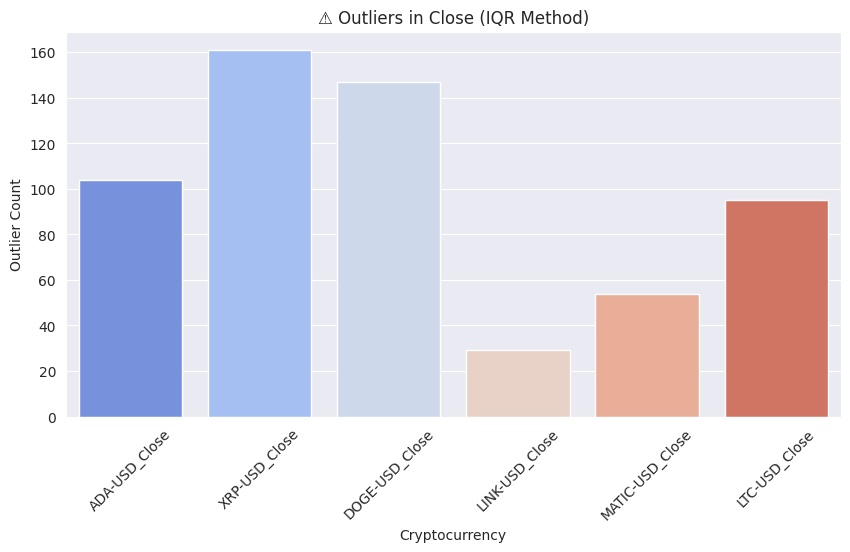

<ipython-input-30-587ba1e46b2a>:80: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




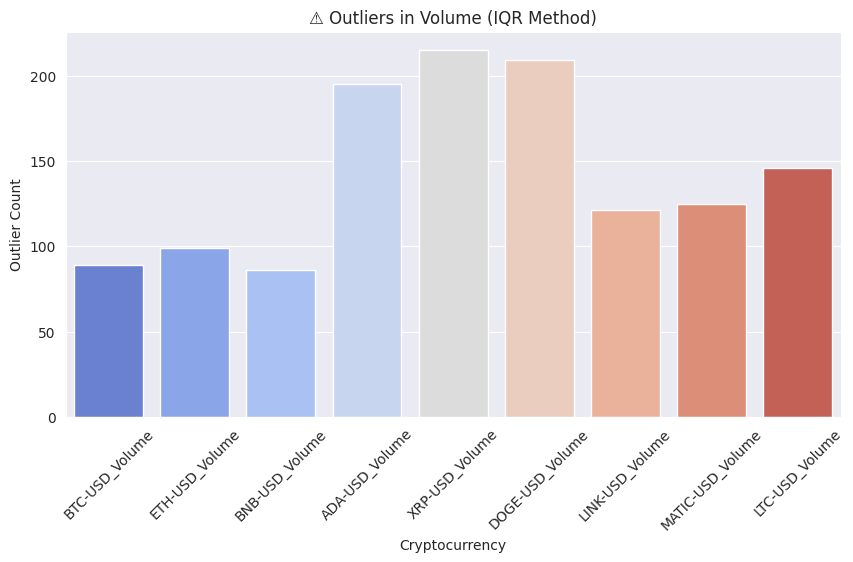

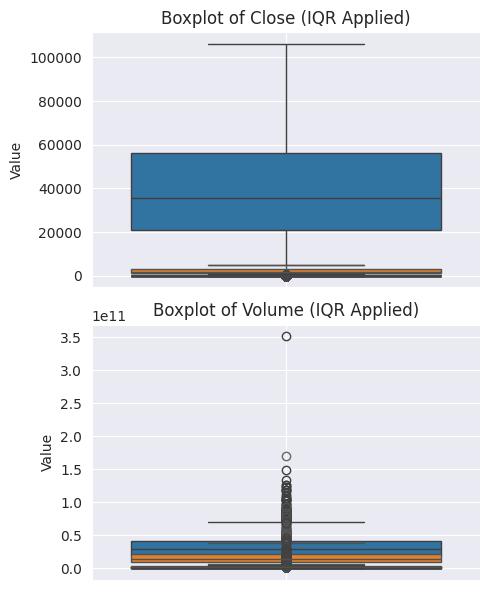

In [30]:
############################### OUTLIER ANALYSIS ###############################
############################### AUTO-DETECT FEATURE GROUPS ###############################

# Extract feature groups dynamically based on column names
feature_groups = {}
for col in final_df.columns:
    feature_type = col.split('_')[-1]  # Extracts 'Close', 'Market_Cap', 'Volume', etc.
    feature_groups.setdefault(feature_type, []).append(col)

print(f"- Automatically detected feature groups: {list(feature_groups.keys())}")

###############################  DYNAMIC GROUPED BOXPLOTS USING PLOTLY ###############################

for feature_type, columns in feature_groups.items():
    fig = go.Figure()
    for col in columns:
        fig.add_trace(go.Box(y=final_df[col].dropna(), name=col, boxmean=True, boxpoints='outliers'))

    fig.update_layout(title=f" {feature_type.replace('_', ' ')} Boxplot",
                      yaxis=dict(title=feature_type),
                      xaxis=dict(title="Cryptocurrency"))
    fig.show()

############################### AUTO-DETECT OUTLIERS (IQR Method) ###############################

outlier_counts = {}

for feature_type, columns in feature_groups.items():
    for col in columns:
        data = final_df[col].dropna()

        # Compute IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        if not outliers.empty:
            outlier_counts[col] = len(outliers)

############################### AUTO-DETECT OUTLIERS (Z-SCORE Method) ###############################

z_score_outliers = {}

for feature_type, columns in feature_groups.items():
    for col in columns:
        data = final_df[col].dropna()
        z_scores = zscore(data)
        outliers = data[(z_scores > 3) | (z_scores < -3)]
        if not outliers.empty:
            z_score_outliers[col] = len(outliers)

###############################  OUTLIER SUMMARY TABLE ###############################
# Structure for summary table
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Total Outliers (IQR)", "Total Outliers (Z-Score)"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        list(outlier_counts.keys()),
        list(outlier_counts.values()),
        [z_score_outliers.get(col, 0) for col in outlier_counts.keys()]
    ],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="- Outlier Summary (IQR & Z-Score)")
fig_summary.show()

###############################  DYNAMIC OUTLIER HISTOGRAMS ###############################
# Define structure for histograms (outliers)
def plot_outlier_histogram(outlier_dict, feature_type):
    """Plots histogram of outliers for a specific feature type."""
    if outlier_dict:
        plt.figure(figsize=(10, 5))
        sns.barplot(x=list(outlier_dict.keys()), y=list(outlier_dict.values()), palette="coolwarm")
        plt.xticks(rotation=45)
        plt.title(f"⚠ Outliers in {feature_type} (IQR Method)")
        plt.xlabel("Cryptocurrency")
        plt.ylabel("Outlier Count")
        plt.show()

# Plot histograms dynamically for each feature group
for feature_type in feature_groups.keys():
    outlier_subset = {k: v for k, v in outlier_counts.items() if k.endswith(feature_type)}
    plot_outlier_histogram(outlier_subset, feature_type)

############################### DYNAMIC INDIVIDUAL CRYPTOCURRENCY BOXPLOTS ###############################
# Structure for boxplots
fig, axes = plt.subplots(nrows=len(feature_groups), ncols=1, figsize=(5, len(feature_groups) * 3))

for i, (feature_type, columns) in enumerate(feature_groups.items()):
    for col in columns:
        data = final_df[col].dropna()

        # Compute IQR for outlier detection
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        # Plot boxplot
        sns.boxplot(y=data, ax=axes[i])
        axes[i].set_title(f"Boxplot of {feature_type} (IQR Applied)")
        axes[i].set_ylabel("Value")
        axes[i].grid(True)

plt.tight_layout()
plt.show()


* Due to the colatile nature of cryptocurrency, no methods will applued for the extreem events as these are importnat in the modleing process and relevant for crypto.

### ***1.2.3 - Data Quality Checks***

- Automatically detected feature groups: ['Close', 'Volume']

- **Running Data Quality Checks Before Splitting...**



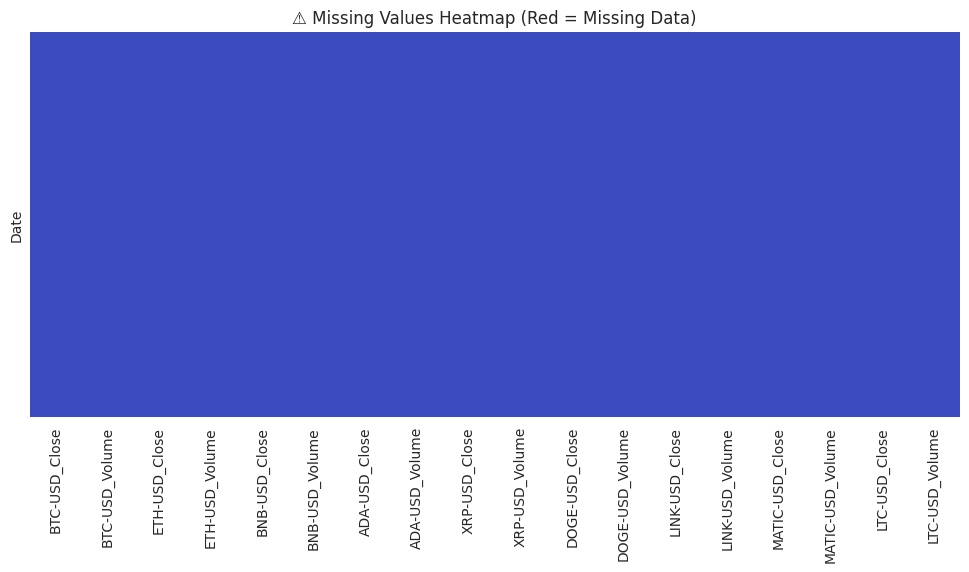


✅ **Data Quality Dashboard Complete! Ready for Feature Engineering.**



In [31]:
############################### DATA QUALITY CHECKS ###############################
############################### AUTO-DETECT FEATURE GROUPS ###############################

# Extract feature groups dynamically based on column names
feature_groups = {}
for col in final_df.columns:
    feature_type = col.split('_')[-1]  # Extracts 'Close', 'Market_Cap', 'Volume', etc.
    feature_groups.setdefault(feature_type, []).append(col)

print(f"- Automatically detected feature groups: {list(feature_groups.keys())}")

############################### DATA QUALITY CHECKS DASHBOARD ###############################
print("\n- **Running Data Quality Checks Before Splitting...**\n")

# Check for duplicate rows
duplicate_rows = final_df.duplicated().sum()

# Check for constant columns (cryptos that might have no variation)
constant_cols = [col for col in final_df.columns if final_df[col].nunique() == 1]

# Check for **negative/zero values** (applies to all detected feature groups)
negative_zero_counts = {
    col: (final_df[col] <= 0).sum()
    for feature, columns in feature_groups.items()
    for col in columns
    if (final_df[col] <= 0).sum() > 0
}

# Ensure the dataset index is **strictly** increasing in time
date_sorted = final_df.index.is_monotonic_increasing

# Check missing values after forward-filling
missing_after_fill = final_df.isnull().sum()
total_missing = missing_after_fill.sum()

# Dataset size
num_rows, num_cols = final_df.shape

############################### PRINT FULL ROWS WITH NEGATIVE OR ZERO VALUES ###############################
if negative_zero_counts:
    print("\n⚠ **Rows with Negative or Zero Values:**\n")
    for col in negative_zero_counts.keys():
        print(f"🔴 {col} has {negative_zero_counts[col]} negative or zero values:")
        display(final_df[final_df[col] <= 0][[col]])

############################### DISPLAY DATA QUALITY SUMMARY ###############################
fig_data_quality = go.Figure(data=[go.Table(
    header=dict(values=["Metric", "Value"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        ["Duplicate Rows", "Constant Value Columns", "Columns with Negative/Zero Values",
         "Dates Sorted", "Total Missing Values", "Dataset Shape"],
        [duplicate_rows, len(constant_cols), len(negative_zero_counts),
         date_sorted, total_missing, f"{num_rows} rows, {num_cols} columns"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_data_quality.update_layout(title_text="- Data Quality Summary")
fig_data_quality.show()

############################### VISUALIZATIONS FOR DATA QUALITY ISSUES ###############################

# Visualizing Missing Values (Heatmap)
plt.figure(figsize=(12, 5))
sns.heatmap(final_df.isnull(), cmap="coolwarm", cbar=False, yticklabels=False)
plt.title("⚠ Missing Values Heatmap (Red = Missing Data)")
plt.show()

# Visualizing **Negative/Zero Values** for All Feature Groups
if negative_zero_counts:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(negative_zero_counts.keys()), y=list(negative_zero_counts.values()), palette="Reds_r")
    plt.xticks(rotation=45)
    plt.title("⚠ Features with Negative/Zero Values")
    plt.xlabel("Feature")
    plt.ylabel("Count of Negative/Zero Values")
    plt.show()

print("\n✅ **Data Quality Dashboard Complete! Ready for Feature Engineering.**\n")


# **2 - Split into Training, Validation & Test Set**
🚀 Time-Based Splitting for Cryptocurrencies (Per Crypto)
Since cryptocurrencies start at different times, the splitting must be done per asset instead of using a fixed percentage across the entire dataset.

📌 Improvements in This Version
✅ Splitting happens per crypto – Each asset gets its own train, validation, and test splits.
✅ Ensures No Data Leakage – Each crypto is split chronologically based on its own history.
✅ Considers Missing Data – Handles cryptos that started later than others.
✅ Output Summary Dashboard – Displays split sizes per crypto in a table.


* CONSIDERATIONS: Very important is to integrate somethign that essentially splits the data into sets based on how much data is available. this si trick but needed because crypto cna be started at any pt in time.

### **2.1 - Time-based Splitting**

In [32]:
###############################  TIME-BASED DATA SPLITTING ###############################
# Define dictionaries to store the split datasets
train_data = {}
val_data = {}
test_data = {}
split_summary = {}

# Perform time-based split on the refined dataset (`df_selected`)
for col in final_df.columns:
    crypto_data = final_df[col].dropna()  # Ensure we're working with non-null data

    if len(crypto_data) < 10:  # Skip cryptos with insufficient data points
        print(f"⚠ Warning: Skipping {col} due to insufficient data points.")
        continue

    # Define split indices (50% train, 25% validation, 25% test)
    train_cutoff = int(len(crypto_data) * 0.5)
    val_cutoff = int(len(crypto_data) * 0.75)

    # Perform individual crypto splits
    train_data[col] = crypto_data.iloc[:train_cutoff]
    val_data[col] = crypto_data.iloc[train_cutoff:val_cutoff]
    test_data[col] = crypto_data.iloc[val_cutoff:]

    # Store split sizes for summary
    split_summary[col] = [len(train_data[col]), len(val_data[col]), len(test_data[col])]

### **2.2 - Elementary Data Analysis On Split Data**

In [33]:
############################### DISPLAY SPLIT SUMMARY ###############################
# Convert split summary to DataFrame
split_df = pd.DataFrame.from_dict(split_summary, orient='index', columns=['Train Size', 'Validation Size', 'Test Size'])

# Create a summary table using Plotly
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Size", "Validation Size", "Test Size"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[split_df.index, split_df["Train Size"], split_df["Validation Size"], split_df["Test Size"]],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="- Time-Based Data Split Summary Per Cryptocurrency")
fig_summary.show()

print(" - **Time-Based Data Splitting Completed!**")

############################### ELEMENTARY STATS FOR SELECTED FEATURES ###############################

# Initialize dictionary to store summary statistics
feature_summary = {}

# For loop
for col in train_data.keys():  # Using train_data since it's the raw prices split
    feature_summary[col] = [
        round(train_data[col].mean(), 2), round(train_data[col].std(), 2),
        round(val_data[col].mean(), 2), round(val_data[col].std(), 2),
        round(test_data[col].mean(), 2), round(test_data[col].std(), 2)
    ]

# Convert dictionary to DataFrame
feature_summary_df = pd.DataFrame.from_dict(
    feature_summary,
    orient='index',
    columns=['Train Mean', 'Train Std', 'Val Mean', 'Val Std', 'Test Mean', 'Test Std']
)

# Plot summary table for feature statistics
fig_feature_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Mean", "Train Std", "Validation Mean", "Validation Std", "Test Mean", "Test Std"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        feature_summary_df.index,
        feature_summary_df["Train Mean"], feature_summary_df["Train Std"],
        feature_summary_df["Val Mean"], feature_summary_df["Val Std"],
        feature_summary_df["Test Mean"], feature_summary_df["Test Std"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_feature_summary.update_layout(title_text="- Feature Statistics Summary Per Cryptocurrency")
fig_feature_summary.show()

print("\n✅ **Feature Statistics Summary Ready!**")


 - **Time-Based Data Splitting Completed!**



✅ **Feature Statistics Summary Ready!**


# **4 - Feature Engineering**

#### 2. Feature Engineering  
- **Log Returns**: Computed as `log(P_t / P_t-1)` to normalize price fluctuations.  
- **Volatility (30-day window)**: Measures market uncertainty.  
- **Simple Moving Averages (SMA)**: 7-day and 30-day smoothing.  
- **Relative Strength Index (RSI)**: Identifies overbought/oversold conditions.  
- **MACD (Moving Average Convergence Divergence)**: Captures trend direction.  


### **4.1 - Feature Engineering Pre-Analysis**

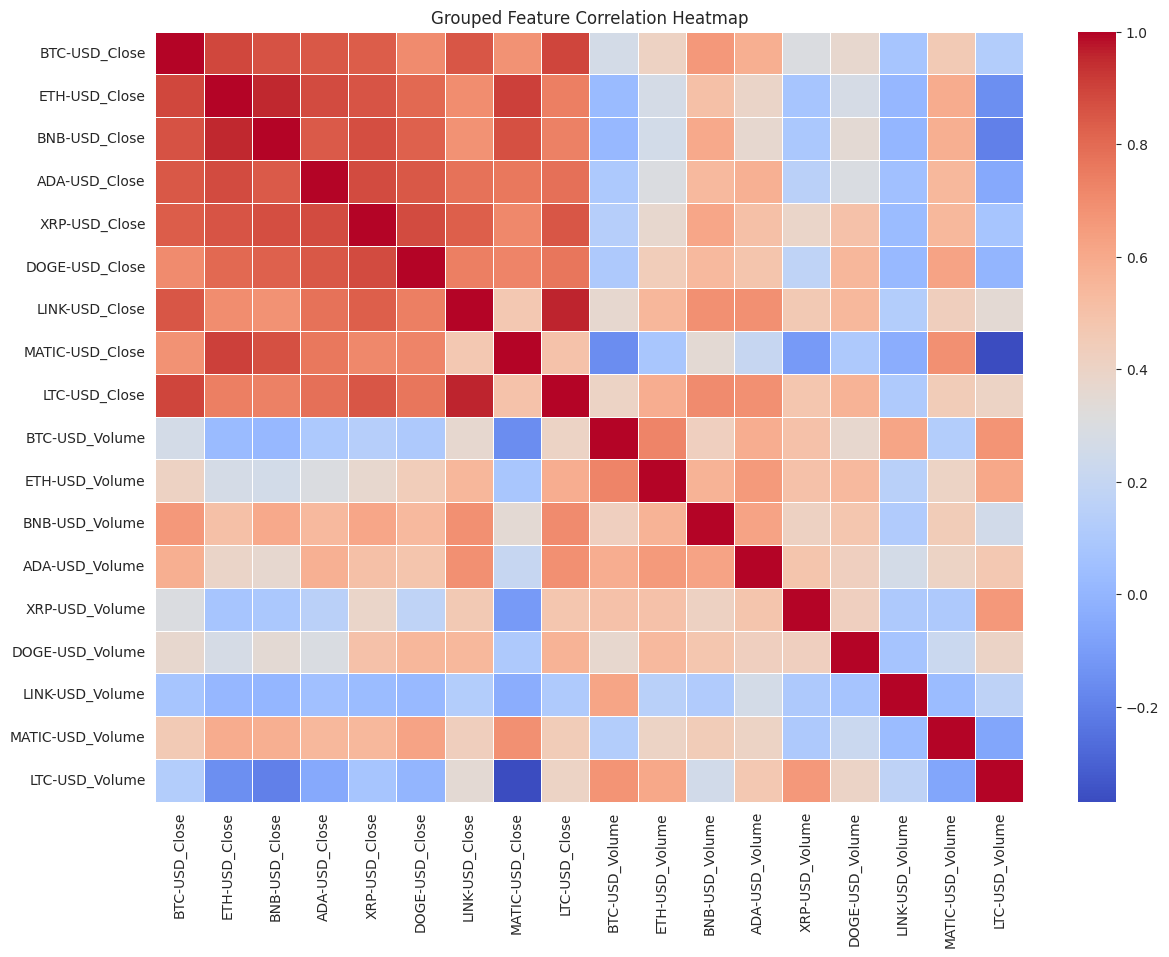


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,BTC-USD_Close,ETH-USD_Close,0.889154
2,BTC-USD_Close,BNB-USD_Close,0.861800
3,BTC-USD_Close,ADA-USD_Close,0.847657
4,BTC-USD_Close,XRP-USD_Close,0.838512
6,BTC-USD_Close,LINK-USD_Close,0.854969
8,BTC-USD_Close,LTC-USD_Close,0.895449
18,ETH-USD_Close,BTC-USD_Close,0.889154
20,ETH-USD_Close,BNB-USD_Close,0.955522
21,ETH-USD_Close,ADA-USD_Close,0.881874
22,ETH-USD_Close,XRP-USD_Close,0.857794


In [34]:
############################### FEATURE ENGINEERING ###############################
# Convert train_data dictionary into a DataFrame
df_features = pd.DataFrame(train_data)  # Merging all crypto series into one DataFrame

# Compute correlation matrix
corr_matrix = df_features.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# Reorder correlation matrix - group by feature group
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# Plot heatmap with grouped features
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Grouped Feature Correlation Heatmap")
plt.xticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=90)
plt.yticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=0)
plt.show()

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

# Print results
print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


📌 Summary of Correlation Analysis
High correlation between Close prices and Market Cap for all cryptocurrencies, indicating redundancy in these features.
Significant cross-cryptocurrency correlations between Cardano and Sui, suggesting linked price movements.
Strong correlations among trading volumes of Bitcoin, Ethereum, Solana, and Cardano, meaning they may share liquidity trends.
Potential Features for Removal: Market Cap (due to redundancy with Close prices), and potentially some volume features to avoid multicollinearity.

### **4.2 - Adding Features**

In [35]:
############################### FEATURE ENGINEERING - ADDING FEATURES ###############################
# Convert `train_data` dictionary into a DataFrame
df_features = pd.DataFrame(train_data)

# Ensure Index is in Proper DateTime Format
df_features.index = pd.to_datetime(df_features.index, errors='coerce')
df_features = df_features.sort_index()

# Initialize Feature Dictionary
new_features = {}

# Iterate over columns and generate only **relevant** features
for col in df_features.columns:
    if '_Close' in col:
        crypto_name = col.replace('_Close', '')

        # Ensure values are numeric to prevent NaN propagation
        df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

        # 1. **Log Returns**
        new_features[f'{crypto_name}_Log_Return'] = np.log(df_features[col] / df_features[col].shift(1))

        # 2.**Rolling Volatility (30-day)**
        new_features[f'{crypto_name}_Volatility_30d'] = (
            new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()
        )

        # 3. **Simple Moving Averages (SMA)**
        new_features[f'{crypto_name}_SMA_7D'] = df_features[col].rolling(window=7).mean()
        new_features[f'{crypto_name}_SMA_30D'] = df_features[col].rolling(window=30).mean()

        # 4. **Relative Strength Index (RSI)**
        delta = df_features[col].diff()
        gain = np.where(delta > 0, delta, 0)
        loss = np.where(delta < 0, -delta, 0)

        avg_gain = pd.Series(gain, index=df_features.index).rolling(window=14, min_periods=1).mean()
        avg_loss = pd.Series(loss, index=df_features.index).rolling(window=14, min_periods=1).mean()

        rs = avg_gain / (avg_loss + 1e-9)  # Avoid division by zero
        new_features[f'{crypto_name}_RSI'] = (100 - (100 / (1 + rs))).round(2)

        # 5. **MACD (Moving Average Convergence Divergence)**
        short_ema = df_features[col].ewm(span=12, adjust=False).mean()
        long_ema = df_features[col].ewm(span=26, adjust=False).mean()
        macd_line = short_ema - long_ema
        signal_line = macd_line.ewm(span=9, adjust=False).mean()

        new_features[f'{crypto_name}_MACD'] = macd_line.round(2)
        new_features[f'{crypto_name}_MACD_Signal'] = signal_line.round(2)

# Convert New Features to DataFrame & Round Values to 2 Decimals
df_new_features = pd.DataFrame(new_features).round(2).fillna(method='bfill').fillna(0)  # Handle missing values

# Identify Log Return Features (For drawdown calculation)
log_return_features = [col for col in df_new_features.columns if '_Log_Return' in col]

if log_return_features:
    print("\n - Computing Drawdowns for Log Returns...")

    def calculate_drawdowns(series):
        """ Optimized drawdown calculation for Log Returns only """
        series = series.replace([np.inf, -np.inf], np.nan).fillna(0)
        cumulative_returns = np.exp(series.cumsum().clip(-50, 50))
        peak = cumulative_returns.cummax()
        drawdown = (cumulative_returns - peak) / peak
        return drawdown.round(2)

    # Apply Drawdown Calculation
    drawdown_features = df_new_features[log_return_features].apply(calculate_drawdowns).add_suffix("_Drawdown")

    # Append Drawdown Features
    df_new_features = pd.concat([df_new_features, drawdown_features], axis=1)

# Combine All Features & Round Again to Ensure Consistency
df_features = pd.concat([df_features, df_new_features], axis=1).round(2)

# Drop NaN values that result from shifting operations
df_features.dropna(inplace=True)

############################### DISPLAY SUMMARY ###############################

print("\n✅ **Feature Engineering Complete! Summary of New Features:**\n")
display(df_features.describe())

# Check Final DataFrame Shape
print("\n - **Final DataFrame Shape:**", df_features.shape)



 - Computing Drawdowns for Log Returns...

✅ **Feature Engineering Complete! Summary of New Features:**



<ipython-input-35-938b9bf75c34>:53: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



,BTC-USD_Close,BTC-USD_Volume,ETH-USD_Close,ETH-USD_Volume,BNB-USD_Close,BNB-USD_Volume,ADA-USD_Close,ADA-USD_Volume,XRP-USD_Close,XRP-USD_Volume,...,LTC-USD_MACD_Signal,BTC-USD_Log_Return_Drawdown,ETH-USD_Log_Return_Drawdown,BNB-USD_Log_Return_Drawdown,ADA-USD_Log_Return_Drawdown,XRP-USD_Log_Return_Drawdown,DOGE-USD_Log_Return_Drawdown,LINK-USD_Log_Return_Drawdown,MATIC-USD_Log_Return_Drawdown,LTC-USD_Log_Return_Drawdown
count,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,...,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000
mean,31609.063308,3.763052e+10,1834.067448,2.011992e+10,250.465279,1.720860e+09,0.837809,2.180011e+09,0.584337,4.094080e+09,...,0.004217,-0.250274,-0.247218,-0.294228,-0.347218,-0.411752,-0.499869,-0.449671,-0.377908,-0.438510
std,17418.750896,1.954623e+10,1325.130995,1.039194e+10,198.837481,1.729390e+09,0.732398,2.544957e+09,0.361792,4.644966e+09,...,8.026742,0.213240,0.212111,0.193344,0.277520,0.226141,0.285573,0.273662,0.223755,0.271229
min,4970.790000,1.225260e+10,110.610000,5.109033e+09,9.390000,1.365992e+08,0.020000,6.484569e+07,0.140000,4.987595e+08,...,-27.150000,-0.720000,-0.770000,-0.710000,-0.860000,-0.820000,-0.920000,-0.900000,-0.880000,-0.890000
25%,11878.370000,2.590558e+10,399.920000,1.343309e+10,28.080000,4.344649e+08,0.120000,6.071842e+08,0.260000,1.628784e+09,...,-3.790000,-0.410000,-0.400000,-0.440000,-0.590000,-0.580000,-0.770000,-0.680000,-0.530000,-0.670000
50%,33746.000000,3.349994e+10,1803.910000,1.755705e+10,286.050000,1.384576e+09,0.640000,1.227753e+09,0.490000,2.380083e+09,...,-0.010000,-0.210000,-0.200000,-0.290000,-0.300000,-0.400000,-0.500000,-0.470000,-0.390000,-0.450000
75%,46188.450000,4.406839e+10,2934.140000,2.357156e+10,405.020000,2.200879e+09,1.310000,2.798264e+09,0.830000,4.325860e+09,...,3.530000,-0.060000,-0.060000,-0.120000,-0.090000,-0.210000,-0.270000,-0.200000,-0.200000,-0.220000
max,67566.830000,3.509679e+11,4812.090000,8.448291e+10,675.680000,1.798295e+10,2.970000,1.914198e+10,1.840000,3.695518e+10,...,25.890000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



 - **Final DataFrame Shape:** (913, 90)


### **4.3 -  Feature Selection**

#### ***4.3.1. - Feature Importance (Random Forests)***


 Training Random Forest for BTC-USD_Log_Return...

Model training complete for BTC-USD_Log_Return!


<ipython-input-36-aa4f02b9092f>:56: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




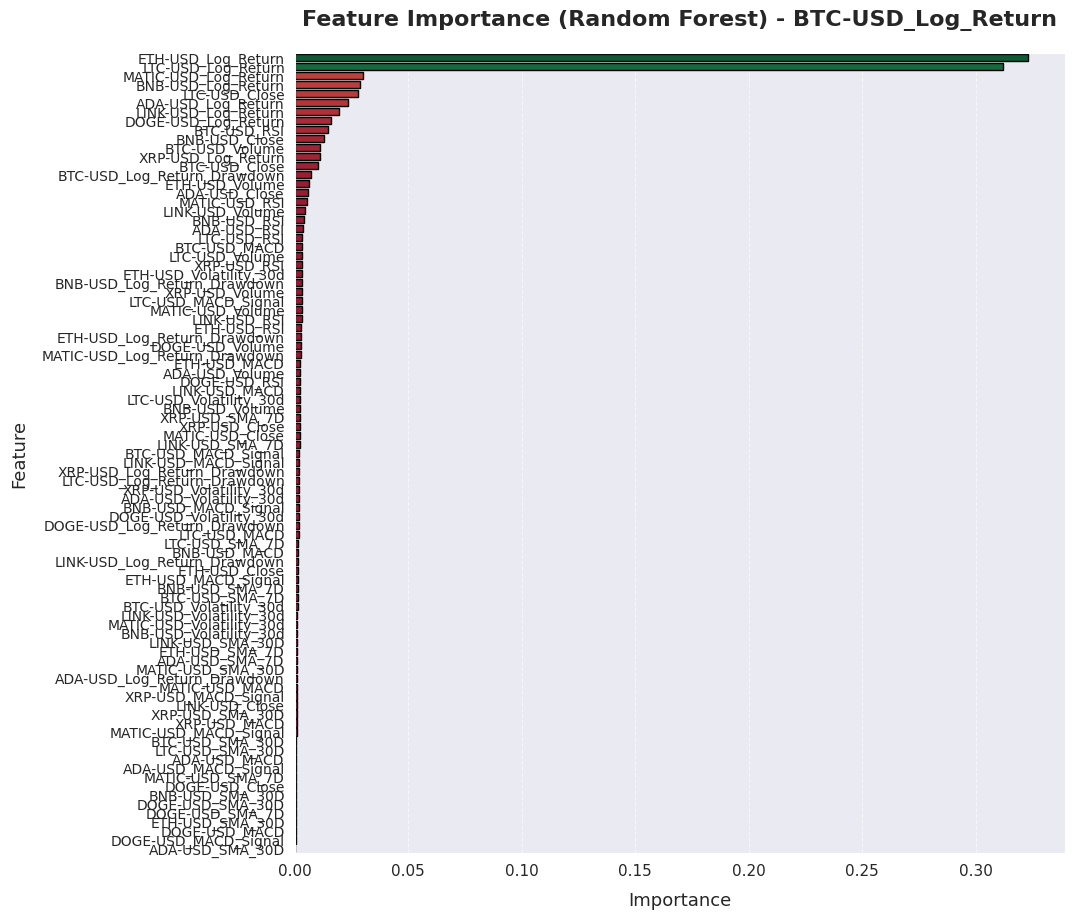

 Selected Features for BTC-USD_Log_Return (Top 10):
['BTC-USD_Close', 'BTC-USD_Volume', 'BTC-USD_RSI', 'ETH-USD_Log_Return', 'BNB-USD_Log_Return', 'DOGE-USD_Log_Return', 'LINK-USD_Log_Return', 'LINK-USD_MACD', 'MATIC-USD_Log_Return', 'LTC-USD_Log_Return']

 **Feature Ranking:**


,Feature,Ranking
0,BTC-USD_Close,1
73,LTC-USD_Log_Return,1
21,BTC-USD_RSI,1
24,ETH-USD_Log_Return,1
64,LINK-USD_MACD,1
...,...,...
27,ETH-USD_SMA_30D,76
58,DOGE-USD_MACD_Signal,77
57,DOGE-USD_MACD,78
54,DOGE-USD_SMA_7D,79



✅ **Multi-Target Feature Importance Analysis Complete for BTC.**


In [36]:
############################### SELECTED TARGET CRYPTOS: BTC, ETH, BNB ###############################
# Set global Seaborn style for clean, professional plots
sns.set_style("darkgrid")

### SELECT TARGET CRYPTO (BTC selected (but tested with ETH and BNB))
# Identify only BTC, ETH, and BNB Log Returns as targets
selected_cryptos = ["BTC-USD_Log_Return"]
log_return_targets = [col for col in df_features.columns if col in selected_cryptos]

# Ensure at least one target is found
if not log_return_targets:
    raise ValueError("❌ No Log Return columns found for BTC, ETH, or BNB. Ensure feature engineering includes log returns.")

# Store feature importance results for BTC, ETH, and BNB
all_feature_importance = {}

# Train a model for each selected cryptocurrency
for target in log_return_targets:
    print(f"\n Training Random Forest for {target}...\n")

    # Define Features & Target
    X = df_features.drop(columns=[target])  # Drop the current target variable
    y = df_features[target]  # Predicting the current crypto's log return

    # Split Data into Train & Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest Model
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    print(f"Model training complete for {target}!")

    ############################### FEATURE IMPORTANCE ANALYSIS ###############################
    # Get Feature Importance Scores
    feature_importances = model.feature_importances_
    features = X.columns

    # Create DataFrame for feature importance
    importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importances}).sort_values(
        by="Importance", ascending=False
    )

    # Normalize importance for color scaling
    importance_df["Normalized"] = (importance_df["Importance"] - importance_df["Importance"].min()) / (
        importance_df["Importance"].max() - importance_df["Importance"].min()
    )

    # Store importance data for all targets
    all_feature_importance[target] = importance_df

    # Define color mapping: Red (low) → Green (high)
    cmap = sns.color_palette("RdYlGn", as_cmap=True)

    # Plot Feature Importance with better spacing
    plt.figure(figsize=(14, 10))  # Increased figure size for better label spacing
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        palette=[cmap(val) for val in importance_df["Normalized"]],
        edgecolor="black"  # Adds a sharp edge to bars for clarity
    )

    plt.title(f"Feature Importance (Random Forest) - {target}", fontsize=16, pad=20, fontweight="bold")
    plt.xlabel("Importance", fontsize=13, labelpad=10)
    plt.ylabel("Feature", fontsize=13, labelpad=10)

    # Improve y-axis label spacing
    plt.yticks(fontsize=10, ha="right")  # Align labels to the right
    plt.xticks(fontsize=11)

    # Adjust subplot to give more space for labels
    plt.subplots_adjust(left=0.4, right=0.95, top=0.9, bottom=0.1)  # Moves labels further from the plot

    plt.grid(axis="x", linestyle="--", alpha=0.6)

    # Show the plot
    plt.show()

    ############################### RECURSIVE FEATURE ELIMINATION (RFE) ###############################
    # Initialize Model for RFE
    estimator = RandomForestRegressor(random_state=42)

    # Apply Recursive Feature Elimination (RFE) to select top 10 features
    num_features_to_select = min(10, X_train.shape[1])  # Ensure we don't select more features than available
    selector = RFE(estimator, n_features_to_select=num_features_to_select, step=1)
    selector.fit(X_train, y_train)

    # Identify Selected Features
    selected_features = X_train.columns[selector.support_]
    print(f" Selected Features for {target} (Top {num_features_to_select}):\n{selected_features.tolist()}")

    # Feature Ranking Table
    ranking_df = pd.DataFrame({"Feature": X_train.columns, "Ranking": selector.ranking_}).sort_values(by="Ranking")

    print("\n **Feature Ranking:**")
    display(ranking_df)

############################### FINAL SUMMARY ###############################

print("\n✅ **Multi-Target Feature Importance Analysis Complete for BTC.**")


### ***4.3.2 - Feature Selection Finalization***

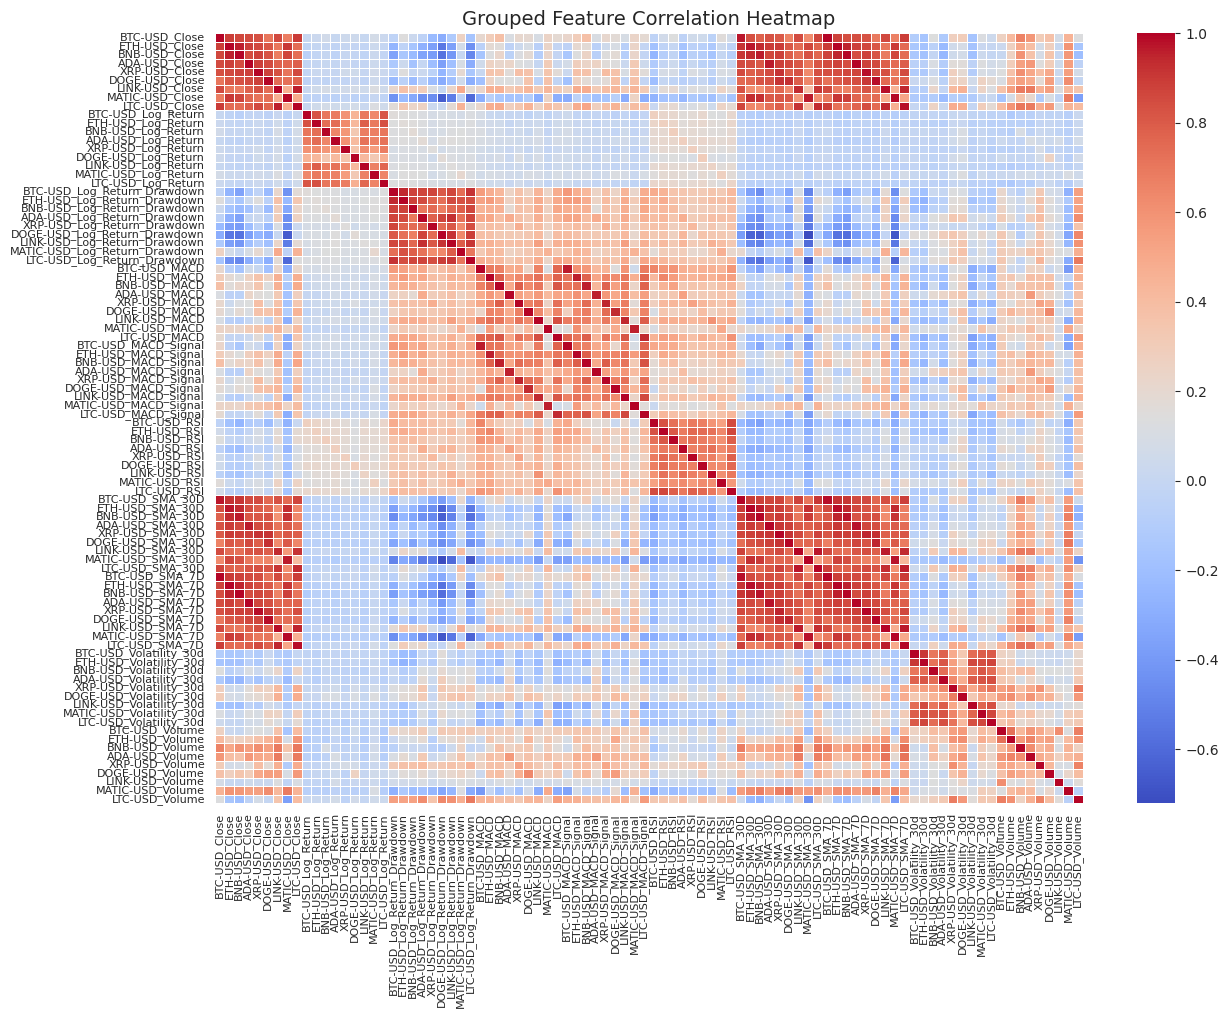


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,BTC-USD_Close,ETH-USD_Close,0.889154
2,BTC-USD_Close,BNB-USD_Close,0.861800
3,BTC-USD_Close,ADA-USD_Close,0.847636
4,BTC-USD_Close,XRP-USD_Close,0.838535
6,BTC-USD_Close,LINK-USD_Close,0.854971
...,...,...,...
7190,MATIC-USD_Volatility_30d,LTC-USD_Volatility_30d,0.862428
7273,LTC-USD_Volatility_30d,ETH-USD_Volatility_30d,0.870471
7275,LTC-USD_Volatility_30d,ADA-USD_Volatility_30d,0.836382
7278,LTC-USD_Volatility_30d,LINK-USD_Volatility_30d,0.832670


In [37]:
############################### FEATURE SELECTION ###############################

# Compute correlation matrix
corr_matrix = df_features.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# Reorder correlation matrix
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Grouped Feature Correlation Heatmap", fontsize=14)

# Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


Based on the correlation results:

Market Cap is highly correlated with Close price (≈0.999+ for all cryptos).
→ Drop Market Cap and keep Close price instead.
Moving Averages (SMA 7d & SMA 30d) are highly correlated with Close (0.85+).
→ Keep one SMA (e.g., SMA 30d) and drop the other.
Cryptos with cross-asset correlations (Cardano & Sui, Bitcoin & Ethereum Log Returns).
→ These may still provide unique insights but should be monitored for redundancy.
Volume-related features have strong correlations (Bitcoin & Ethereum Volume, 0.87+).
→ Drop MarketCap-to-Volume Ratio if it's redundant.


In [38]:
############################### ✅ FEATURE SELECTION (Optimized for Portfolio Optimization) ###############################

# ✅ Step 1: Define Feature Removal Flags
remove_sma = True  # Remove all SMA features (_SMA_7d and _SMA_30d)
remove_market_cap = True  # Remove all _Market_Cap features
remove_marketcap_to_volume = True  # Remove all _MarketCap_to_Volume features
remove_volume = True  # Remove all _Volume features (including _Volume_Change)
remove_macd = False  # Remove all _MACD features
remove_rsi = False  # Remove all _RSI features
remove_log_return_drawdown = True  # Remove all _Log_Return_Drawdown features

# ✅ Step 2: Identify Columns to Remove
features_to_drop = []

for col in df_features.columns:
    if remove_sma and ("_SMA_7D" in col or "_SMA_30D" in col):
        features_to_drop.append(col)
    if remove_market_cap and "_Market_Cap" in col: # if we readd marketcap
        features_to_drop.append(col)
    if remove_marketcap_to_volume and "_MarketCap_to_Volume" in col: # based on addiiton of marketcap
        features_to_drop.append(col)
    if remove_volume and ("_Volume" in col or "_Volume_Change" in col):
        features_to_drop.append(col)
    if remove_macd and "_MACD" in col:
        features_to_drop.append(col)
    if remove_rsi and "_RSI" in col:
        features_to_drop.append(col)
    if remove_log_return_drawdown and "_Log_Return_Drawdown" in col:
        features_to_drop.append(col)

# ✅ Step 3: Drop Selected Features
df_selected = df_features.drop(columns=features_to_drop, errors='ignore')

# ✅ Step 4: Confirm Shape After Feature Selection
print("\n✅ **Feature Selection Completed! Final Data Shape:**", df_selected.shape)
print(f"📌 Removed {len(features_to_drop)} Features")
display(df_selected.head())



✅ **Feature Selection Completed! Final Data Shape:** (913, 54)
📌 Removed 36 Features


,BTC-USD_Close,ETH-USD_Close,BNB-USD_Close,ADA-USD_Close,XRP-USD_Close,DOGE-USD_Close,LINK-USD_Close,MATIC-USD_Close,LTC-USD_Close,BTC-USD_Log_Return,...,MATIC-USD_Log_Return,MATIC-USD_Volatility_30d,MATIC-USD_RSI,MATIC-USD_MACD,MATIC-USD_MACD_Signal,LTC-USD_Log_Return,LTC-USD_Volatility_30d,LTC-USD_RSI,LTC-USD_MACD,LTC-USD_MACD_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-01,8562.45,218.97,18.96,0.05,0.23,0.0,3.88,0.02,57.96,0.04,...,0.09,0.16,0.0,0.0,0.0,0.05,0.11,0.00,0.00,0.00
2020-03-02,8869.67,230.57,19.81,0.05,0.24,0.0,4.22,0.02,61.00,0.04,...,0.09,0.16,100.0,0.0,0.0,0.05,0.11,100.00,0.24,0.05
2020-03-03,8787.79,224.48,19.64,0.05,0.23,0.0,4.58,0.02,61.14,-0.01,...,0.10,0.16,100.0,0.0,0.0,0.00,0.11,100.00,0.44,0.13
2020-03-04,8755.25,224.52,19.96,0.05,0.23,0.0,4.64,0.03,60.38,-0.00,...,0.07,0.16,100.0,0.0,0.0,-0.01,0.11,80.71,0.53,0.21
2020-03-05,9078.76,229.27,20.80,0.05,0.24,0.0,4.72,0.03,62.05,0.04,...,0.05,0.16,100.0,0.0,0.0,0.03,0.11,86.42,0.73,0.31


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



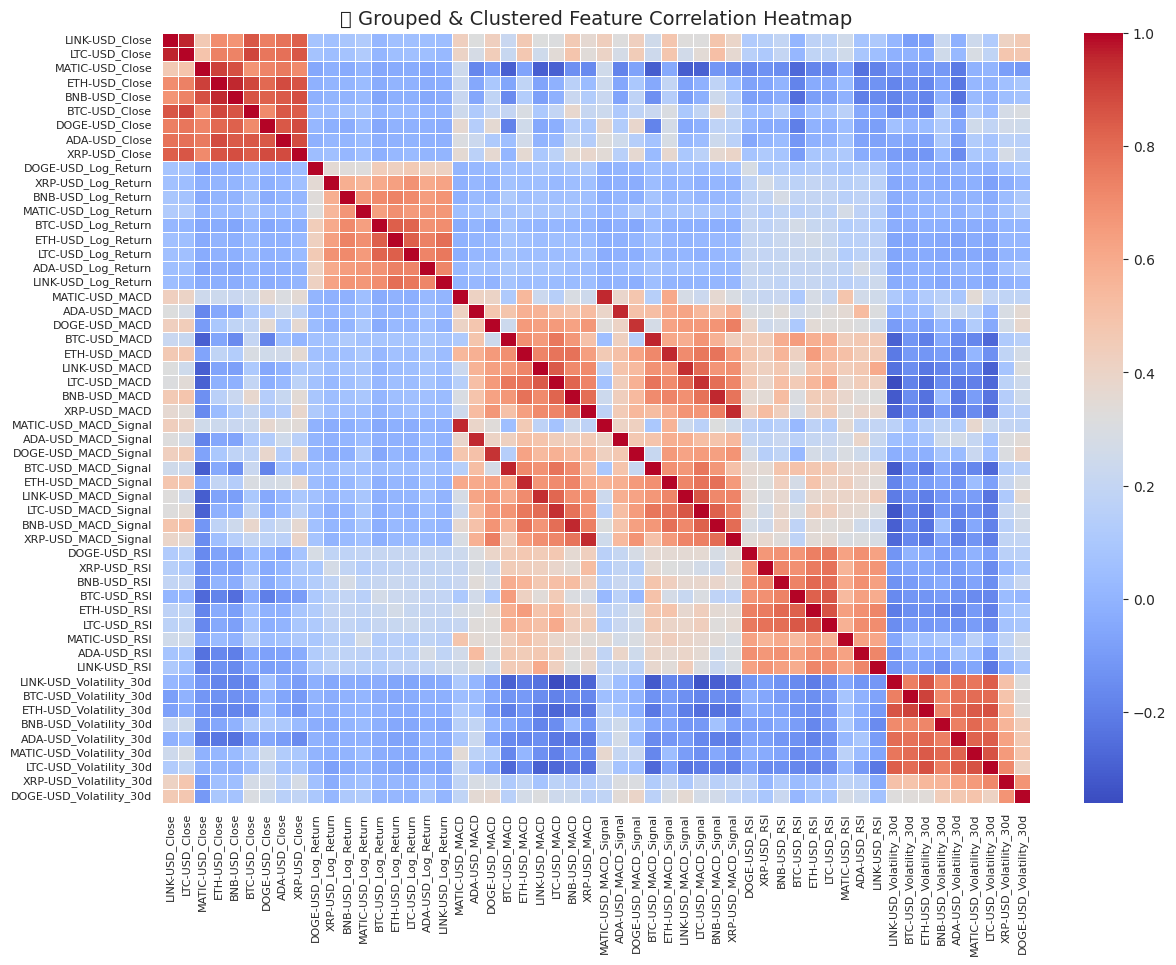


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,LINK-USD_Close,LTC-USD_Close,0.958220
5,LINK-USD_Close,BTC-USD_Close,0.854971
8,LINK-USD_Close,XRP-USD_Close,0.834097
54,LTC-USD_Close,LINK-USD_Close,0.958220
59,LTC-USD_Close,BTC-USD_Close,0.895449
...,...,...,...
2751,MATIC-USD_Volatility_30d,LTC-USD_Volatility_30d,0.862428
2799,LTC-USD_Volatility_30d,LINK-USD_Volatility_30d,0.832670
2801,LTC-USD_Volatility_30d,ETH-USD_Volatility_30d,0.870471
2803,LTC-USD_Volatility_30d,ADA-USD_Volatility_30d,0.836382


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list

############################### 📊 Dynamic Feature Grouping ###############################

# ✅ Step 1: Compute correlation matrix
corr_matrix = df_selected.corr()

# ✅ Step 2: Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# ✅ Step 3: Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_selected.columns}

# ✅ Step 4: Sort features by group name
sorted_features = sorted(df_selected.columns, key=lambda x: feature_groups[x])

# ✅ Step 5: Apply Hierarchical Clustering Within Each Group
final_sorted_features = []
unique_groups = sorted(set(feature_groups.values()))  # Unique sorted group names

for group in unique_groups:
    group_features = [f for f in sorted_features if feature_groups[f] == group]

    if len(group_features) > 1:  # Only apply clustering if multiple features exist
        sub_corr_matrix = df_selected[group_features].corr()

        if not sub_corr_matrix.isnull().values.all():  # Ensure clustering is possible
            linked = linkage(sub_corr_matrix.fillna(0), method='ward')
            ordered_indices = leaves_list(linked)
            ordered_group_features = [group_features[i] for i in ordered_indices]
        else:
            ordered_group_features = group_features  # No clustering needed

        final_sorted_features.extend(ordered_group_features)
    else:
        final_sorted_features.extend(group_features)

# ✅ Step 6: Reorder correlation matrix with new feature ordering
corr_matrix = corr_matrix.loc[final_sorted_features, final_sorted_features]

# ✅ Step 7: Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("📊 Grouped & Clustered Feature Correlation Heatmap", fontsize=14)

# ✅ Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

############################### ⚠ Identifying Highly Correlated Features ###############################

# ✅ Step 8: Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


# **5 - Data Analysis**

## **Exploratory Data Analysis (EDA)**  
#### **1. Summary Statistics**  
- BTC, ETH, and BNB exhibit **high market capitalization and lower volatility** compared to altcoins.  
- DOGE, MATIC, and LINK have **higher volatility**, indicating greater price swings.  

#### **2. Data Visualizations**  
- **Boxplots** revealed significant outliers, particularly in **DOGE** and **MATIC**.  
- **Histograms** demonstrated skewed price distributions for most cryptocurrencies.  
- **Correlation Matrix** highlighted strong relationships between BTC and ETH (`ρ > 0.88`).  

---


## **5.1 - Statistical Summary**

In [40]:
############################### FEATURE SUMMARY ANALYSIS (All Features) ###############################
# Identify Feature Groups Dynamically
feature_summary = {}

for col in df_selected.columns:
    # Extract feature category dynamically
    match = re.search(r'_(Close|SMA_\d+d|Log_Return|Volatility_\d+d|Volume|MarketCap_to_Volume|RSI|MACD)$', col)

    if match:
        feature_type = match.group(1)  # Extract feature type
        crypto_name = col.replace(f"_{feature_type}", "")  # Extract crypto name
        data = df_selected[col].dropna()  # Drop NaN values

        # Compute statistics only if there is sufficient data
        if len(data) > 1:
            if feature_type not in feature_summary:
                feature_summary[feature_type] = {}

            feature_summary[feature_type][crypto_name] = [
                round(data.count(), 4), round(data.mean(), 4), round(data.std(), 4),
                round(data.max() - data.min(), 4), round(median_abs_deviation(data), 4),
                round(skew(data), 4), round(kurtosis(data), 4),
                round(data.min(), 4), round(data.quantile(0.25), 4),
                round(data.median(), 4), round(data.quantile(0.75), 4), round(data.max(), 4)
            ]

# Convert to DataFrames & Plot
summary_columns = ['Count', 'Mean', 'Std Dev', 'Range', 'MAD', 'Skewness', 'Kurtosis',
                   'Min', '25%', '50% (Median)', '75%', 'Max']

# Generate Summary Tables for Each Feature Type
for feature_type, summary_data in feature_summary.items():
    feature_summary_df = pd.DataFrame.from_dict(summary_data, orient='index', columns=summary_columns)

    # Drop NaN values before plotting
    feature_summary_df.dropna(inplace=True)

    # Plotly Table for each feature type
    fig = go.Figure(data=[go.Table(
        columnwidth=[150] + [70] * len(feature_summary_df.columns),  # Adjust width dynamically
        header=dict(values=["Cryptocurrency"] + list(feature_summary_df.columns),
                    fill_color='paleturquoise',
                    align='left'),
        cells=dict(values=[
            feature_summary_df.index,  # Ensure longer column width for crypto names
            feature_summary_df["Count"], feature_summary_df["Mean"], feature_summary_df["Std Dev"],
            feature_summary_df["Range"], feature_summary_df["MAD"],
            feature_summary_df["Skewness"], feature_summary_df["Kurtosis"],
            feature_summary_df["Min"], feature_summary_df["25%"], feature_summary_df["50% (Median)"],
            feature_summary_df["75%"], feature_summary_df["Max"]
        ],
        fill_color='lavender',
        align='left'))
    ])

    # Update layout
    fig.update_layout(title_text=f"- Statistical Summary ({feature_type})")
    fig.show()

    print(f"\n✅ **Dashboard-Style Summary Completed for {feature_type}!**")



✅ **Dashboard-Style Summary Completed for Close!**



✅ **Dashboard-Style Summary Completed for Log_Return!**



✅ **Dashboard-Style Summary Completed for Volatility_30d!**



✅ **Dashboard-Style Summary Completed for RSI!**



✅ **Dashboard-Style Summary Completed for MACD!**


<!--  -->

## **5.2 - Data Visualizations**

### ***5.2.1 - Histogram & KDE***

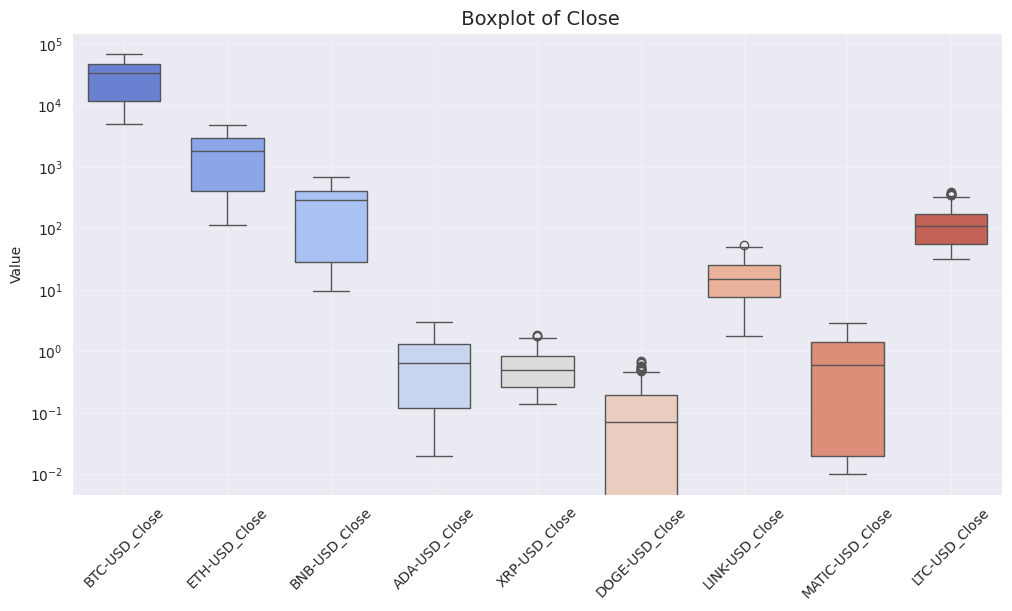

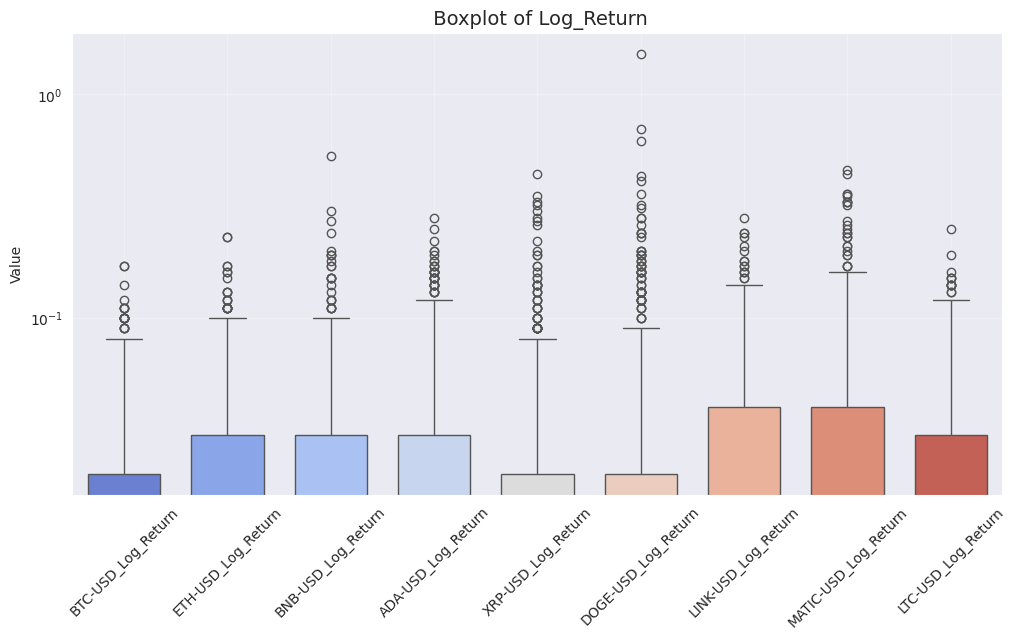

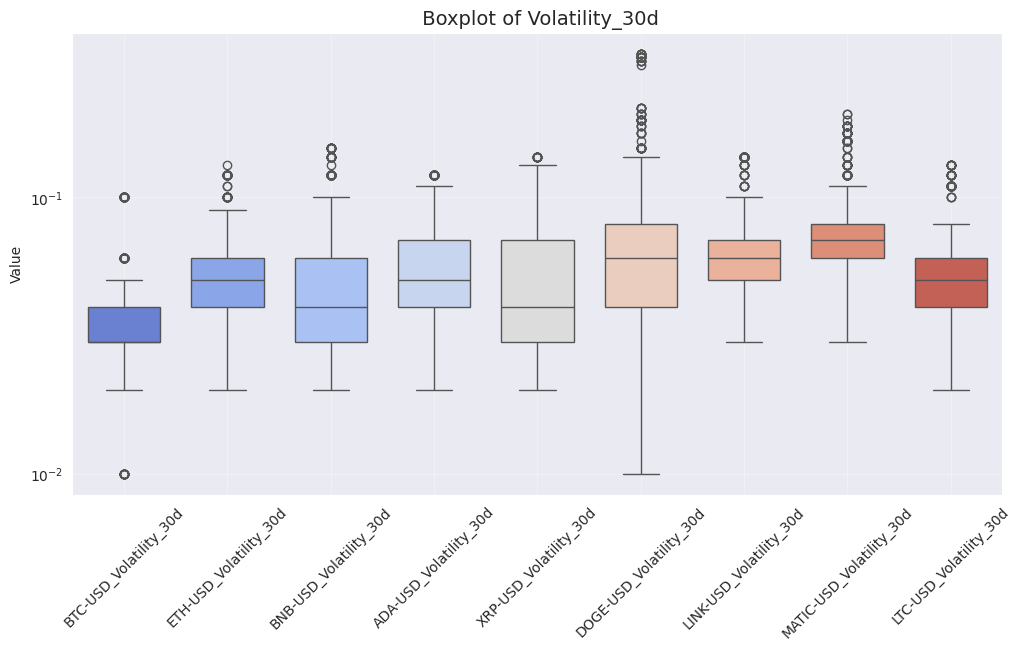

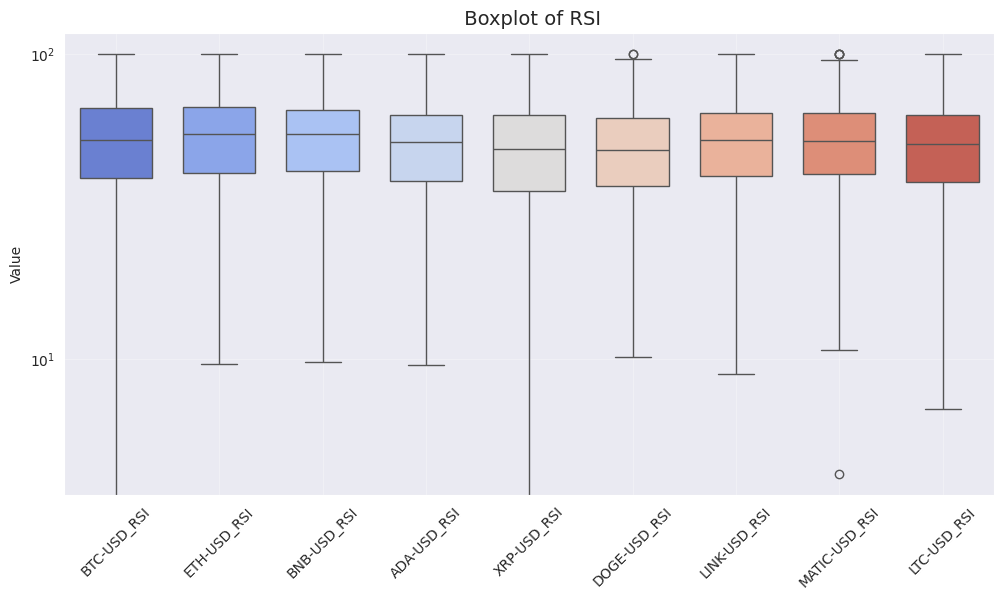

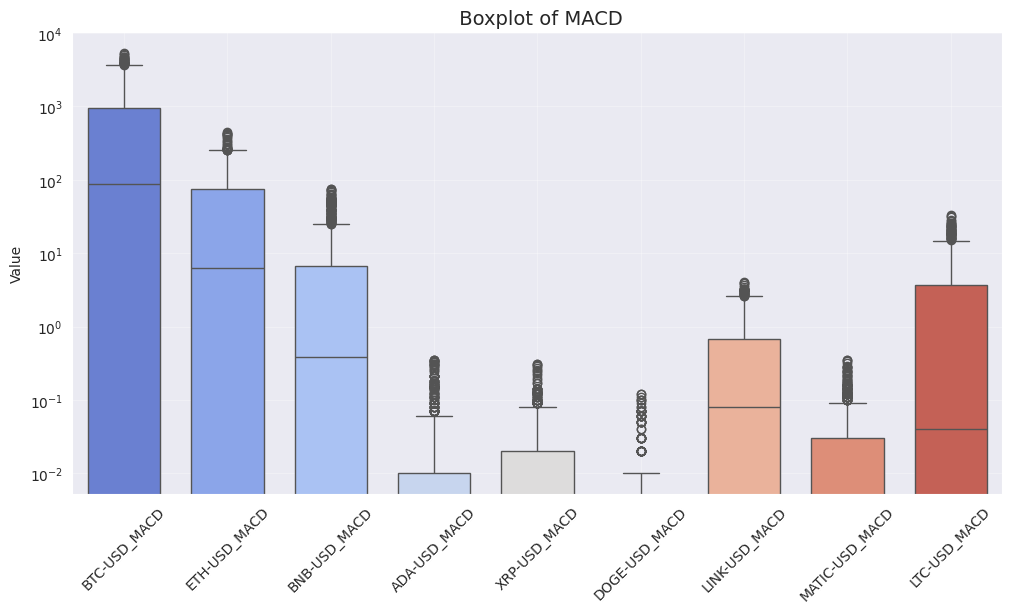

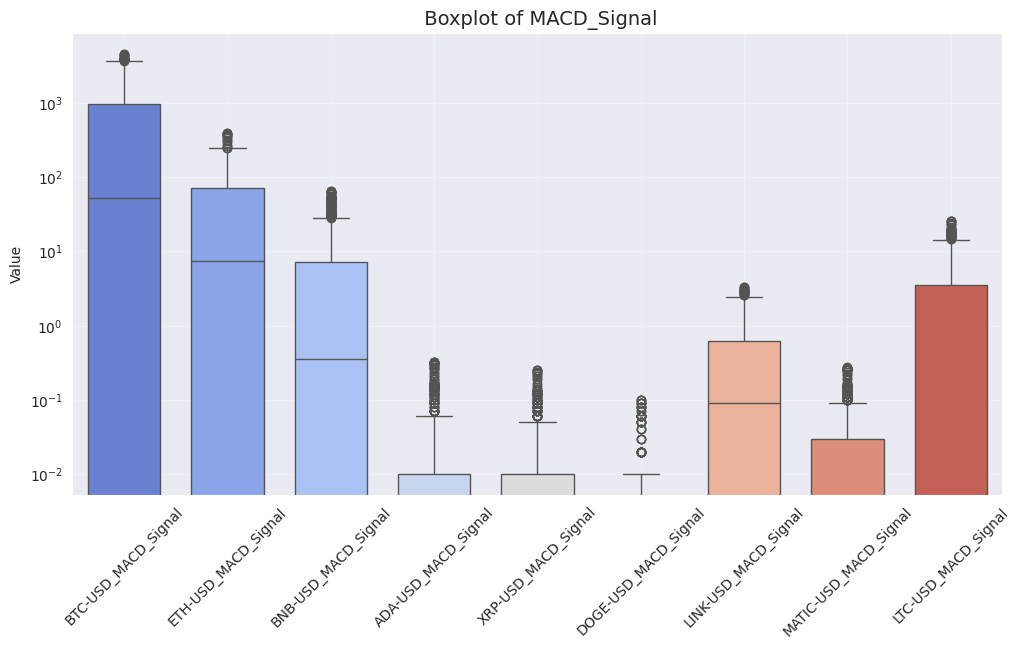

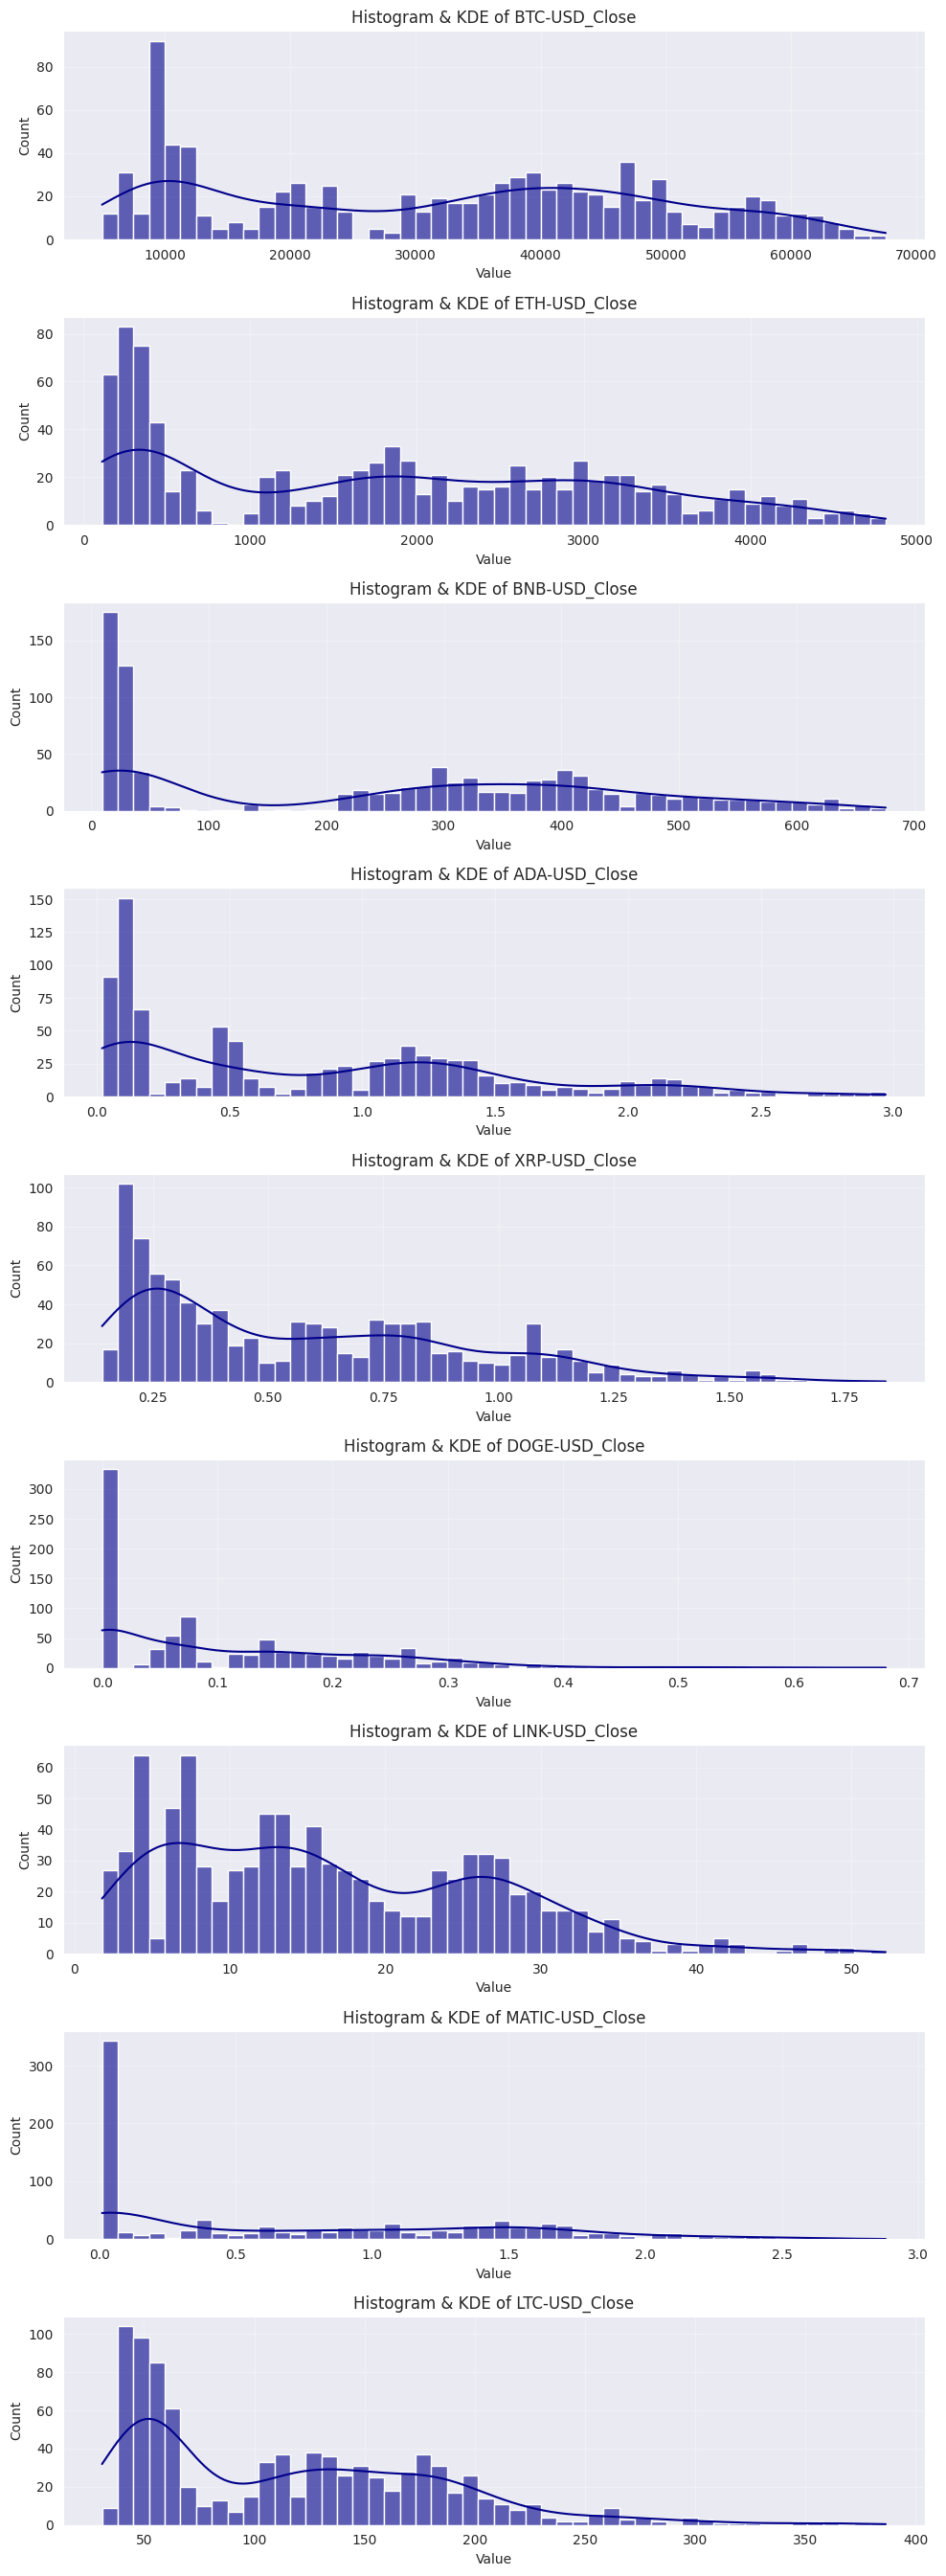

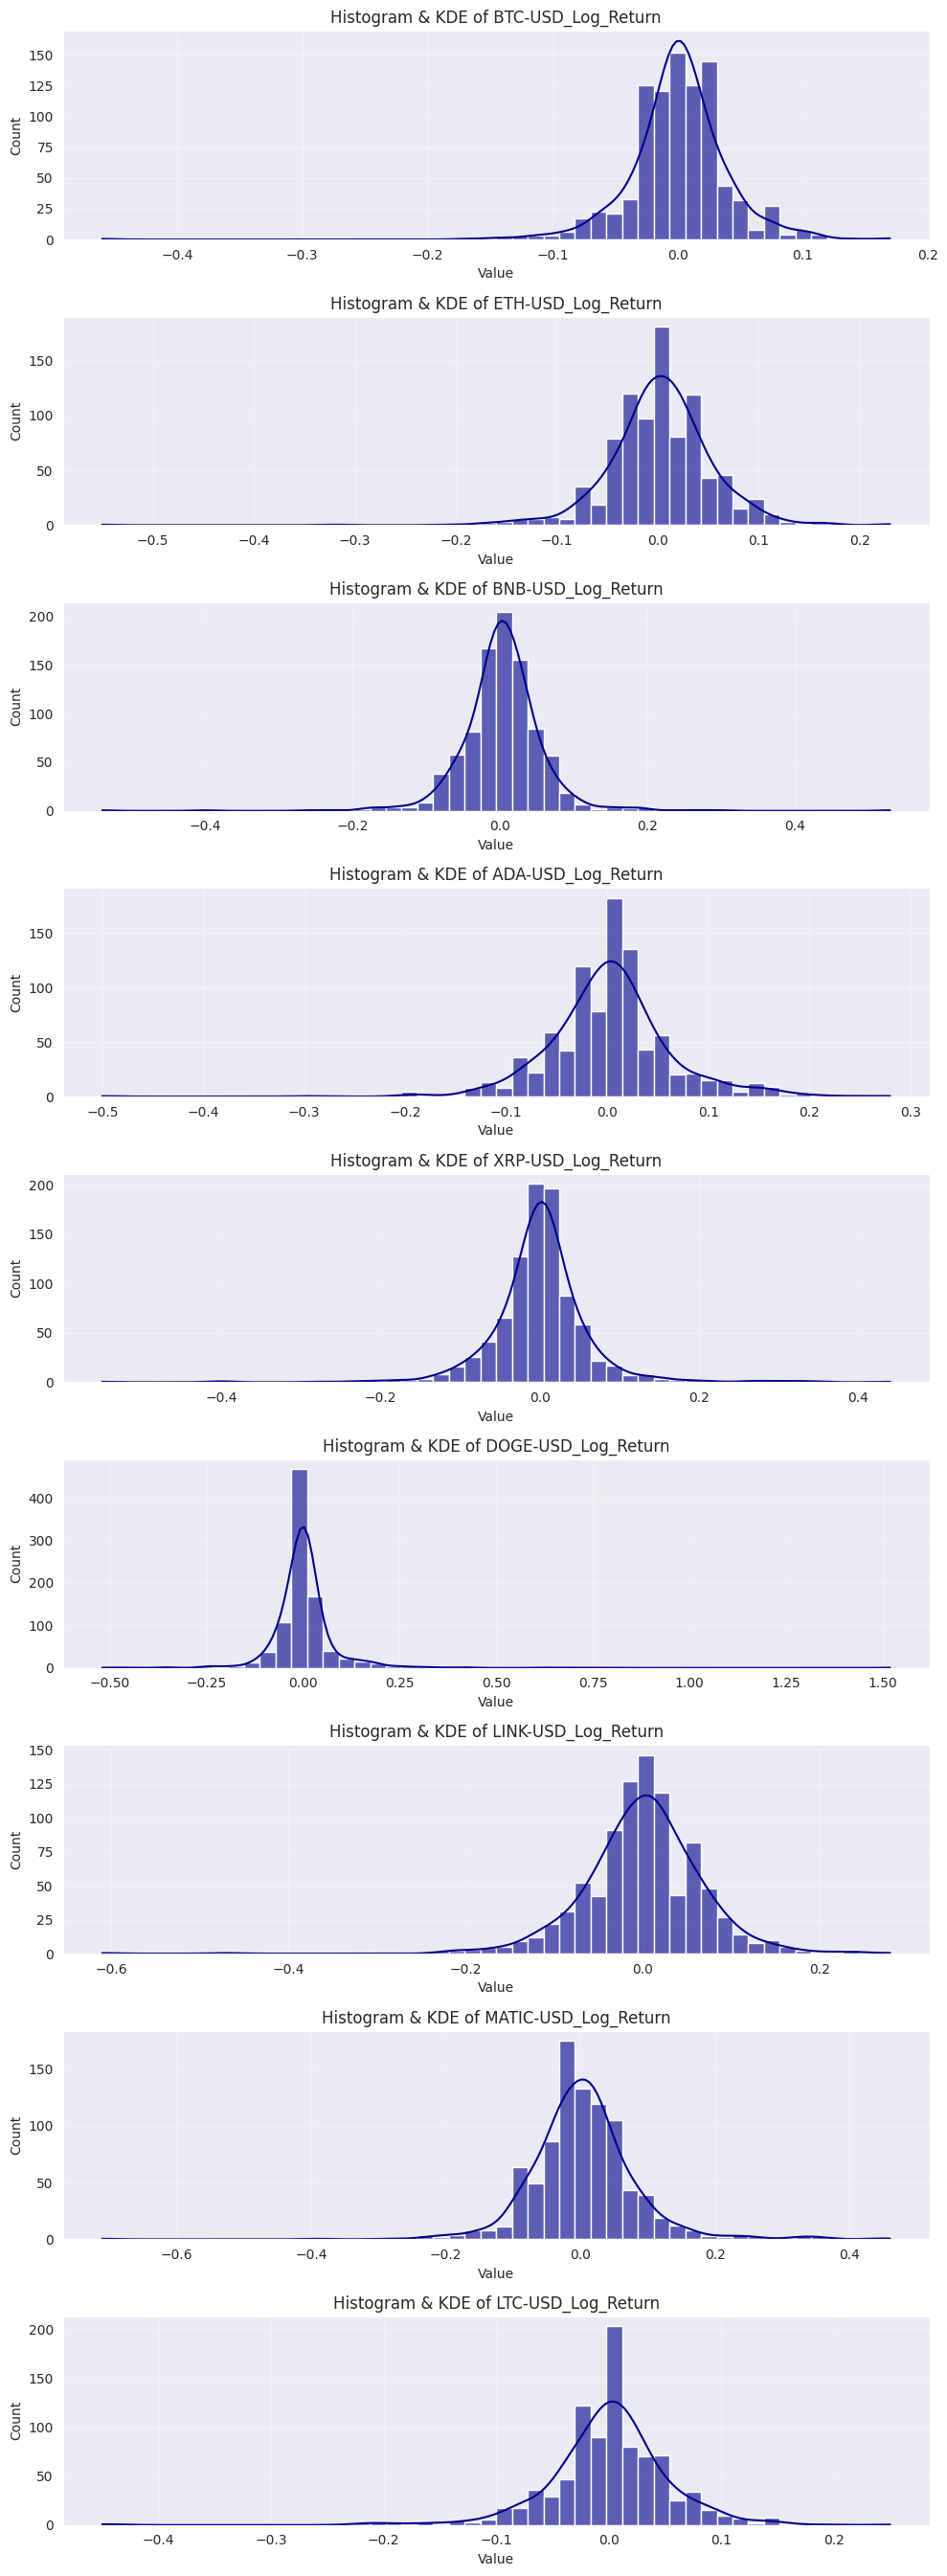

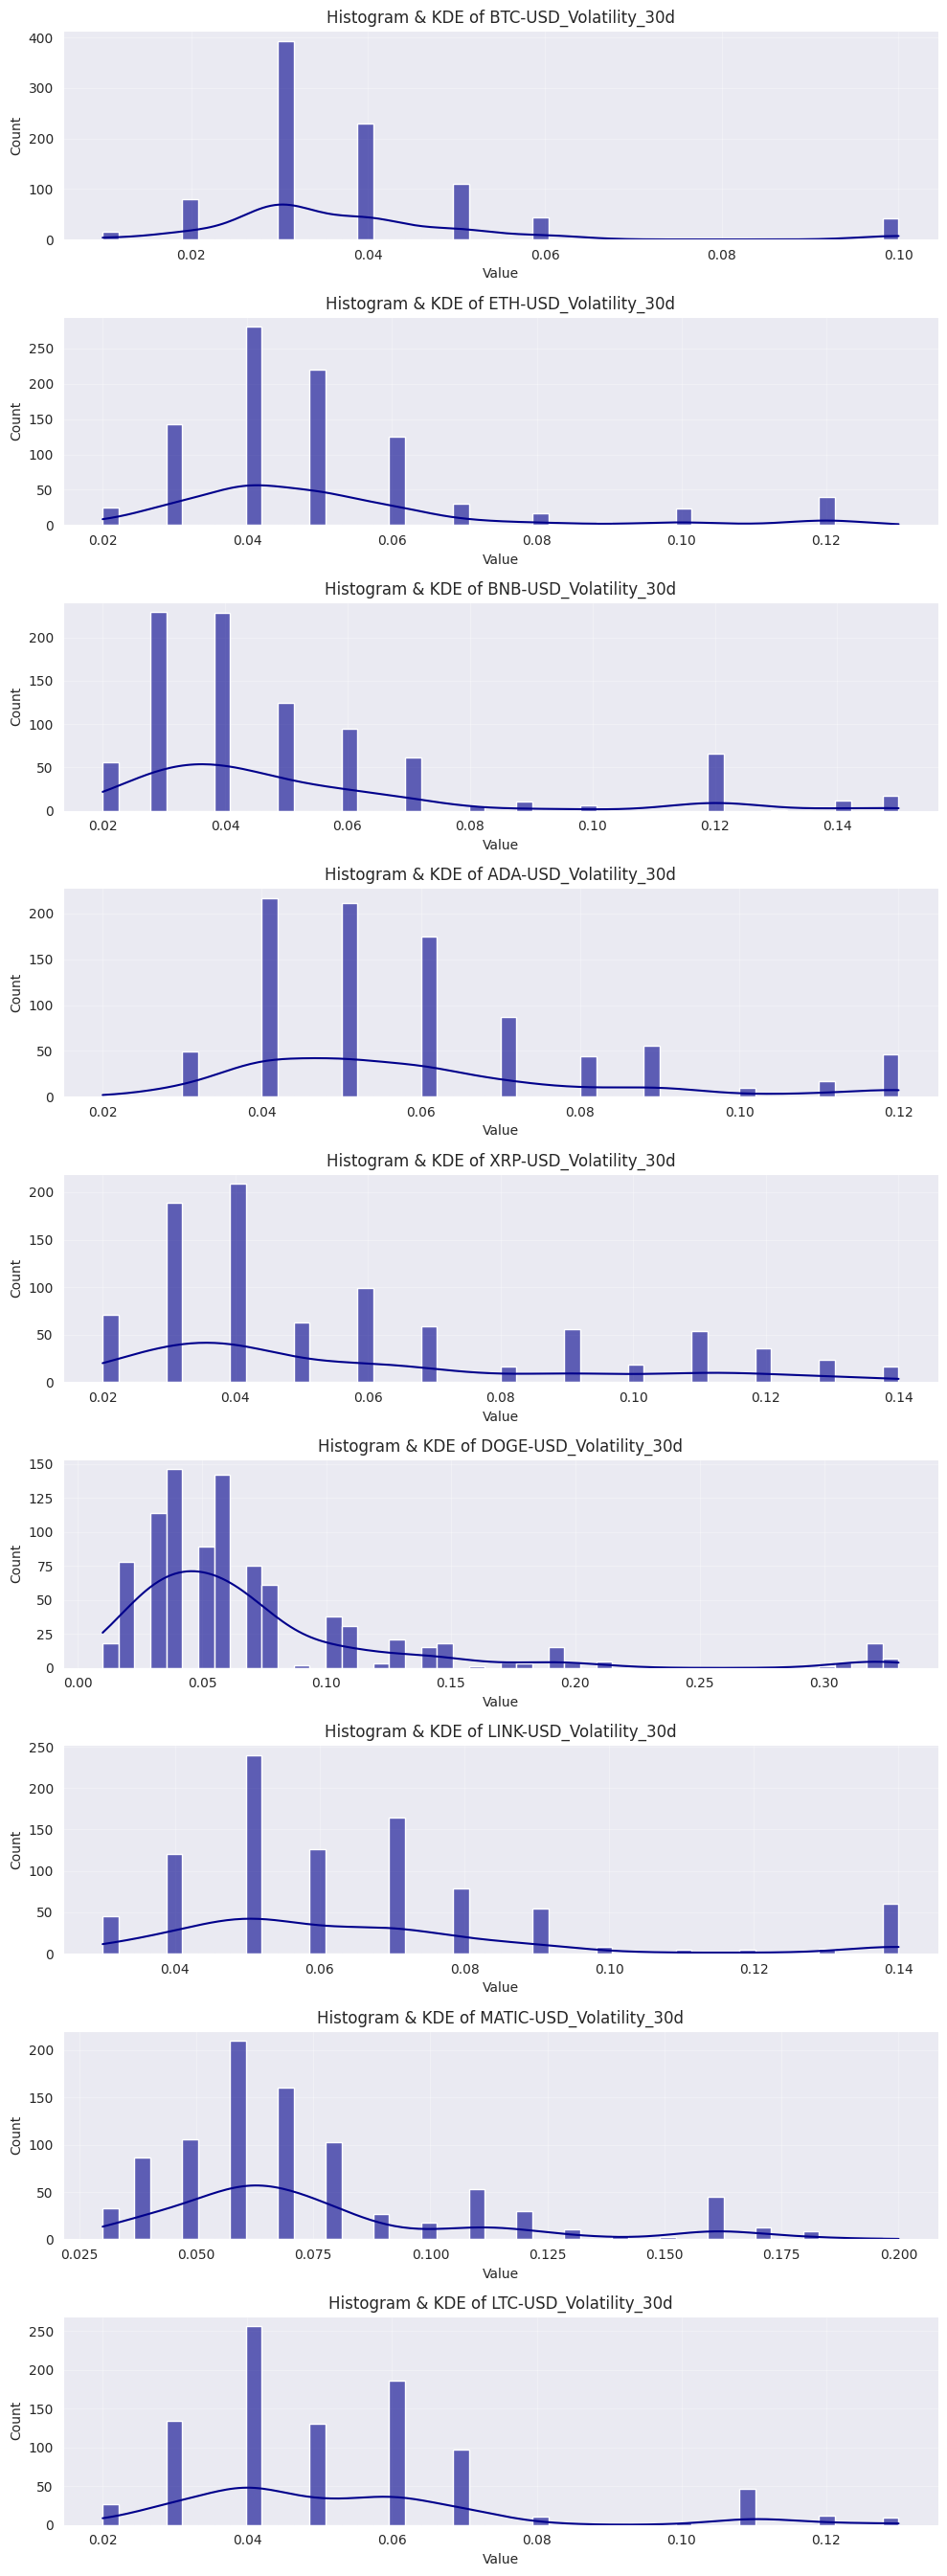

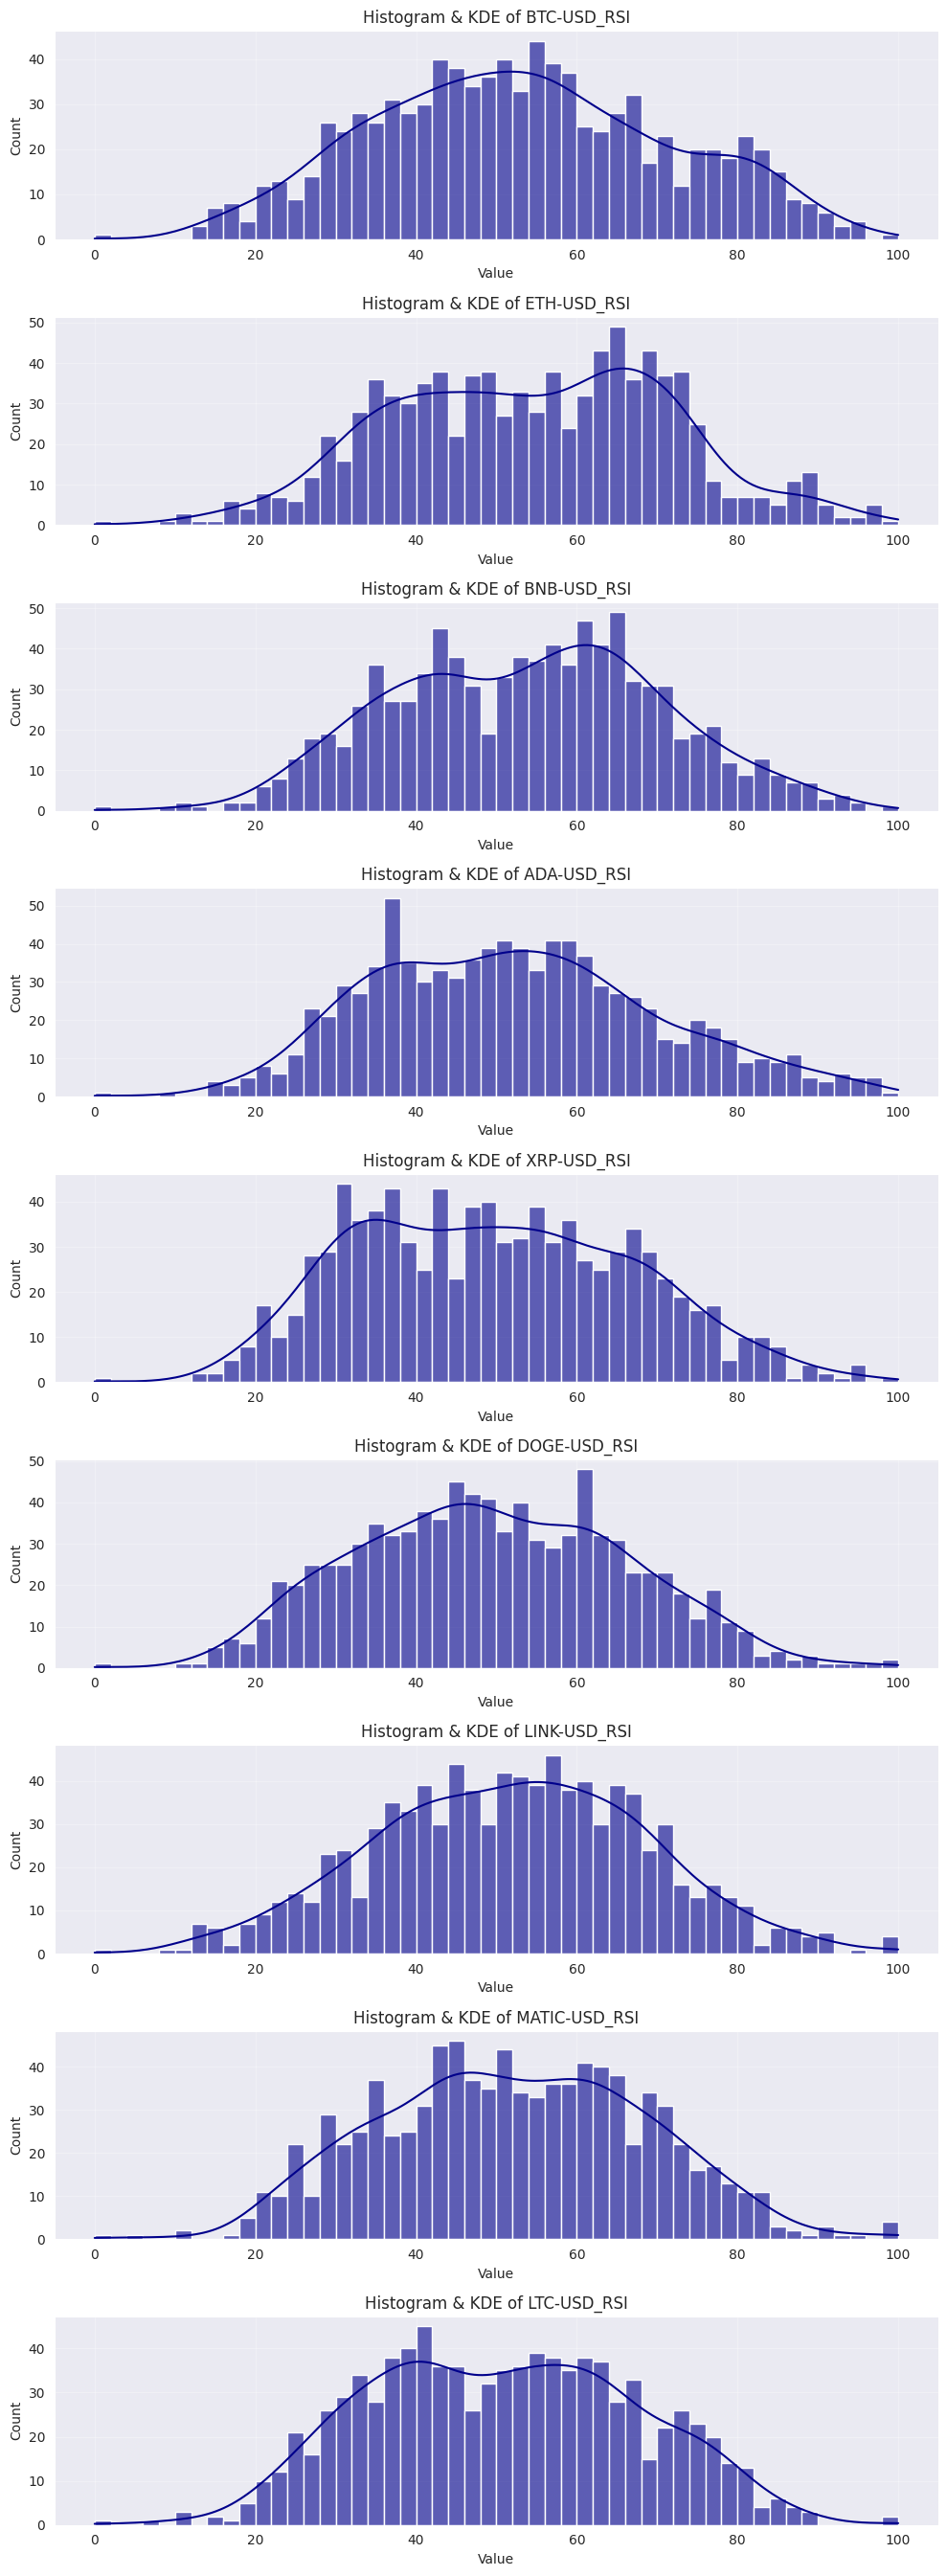

In [ ]:
############################### AUTO-DETECT FEATURE GROUPS ###############################
# Identify Unique Feature Groups Based on Column Names
feature_groups = {}
for col in df_selected.columns:
    # Extract feature type (assumes naming convention "{crypto}_{feature}")
    feature_type = col.split("_", 1)[-1]  # Everything after the first "_"

    # Add to dictionary
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### BOXPLOTS: DYNAMICALLY GROUPED FEATURES ###############################

# Function to Plot Boxplots
def plot_boxplot(feature_list, title):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_selected[feature_list], showfliers=True, width=0.7, palette="coolwarm")
    plt.yscale("log")  # Log scale for better visualization
    plt.title(f" {title}", fontsize=14)
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.show()

# Generate Boxplots for Each Feature Group
for group_name, feature_list in feature_groups.items():
    plot_boxplot(feature_list, f"Boxplot of {group_name}")

############################### HISTOGRAMS + KDE PLOTS ###############################

# Function to Plot Histograms & KDE
def plot_histogram(feature_list, title, color="blue"):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    fig, axes = plt.subplots(nrows=len(feature_list), ncols=1, figsize=(10, len(feature_list) * 3))

    for i, col in enumerate(feature_list):
        sns.histplot(df_selected[col], kde=True, bins=50, ax=axes[i], color=color, alpha=0.6)
        axes[i].set_title(f"Histogram & KDE of {col}", fontsize=12)
        axes[i].set_xlabel("Value")
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Generate Histograms for Each Feature Group
for group_name, feature_list in feature_groups.items():
    plot_histogram(feature_list, f"Histogram & KDE of {group_name}", color="darkblue")

print("\n✅ **Dynamic Feature Grouping & Visualization Completed!**")


### ***5.2.2 - Risk vs Return***

In [ ]:
############################### COMPUTE MEAN & VOLATILITY ###############################
# Calculate Mean & Volatility (Standard Deviation)
returns_volatility = pd.DataFrame({
    "Mean Value": df_selected.mean(),
    "Volatility (Std Dev)": df_selected.std()
})

############################### AUTO-DETECT FEATURE GROUPS ###############################
feature_groups = {}
for col in df_selected.columns:
    # Extract feature type dynamically
    feature_type = col.split("_", 1)[-1]  # Everything after first "_"

    # Add to dictionary
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### SCATTER PLOTS: RISK VS RETURN ###############################

# Function to Generate Scatter Plots
def plot_scatter(feature_list, title):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    subset_df = returns_volatility.loc[feature_list]  # Filter relevant features

    fig = px.scatter(
        subset_df,
        x="Volatility (Std Dev)",
        y="Mean Value",
        text=subset_df.index,
        size_max=15,
        color=subset_df.index,
        title=title
    )

    fig.update_traces(textposition='top center')
    fig.update_layout(xaxis_title="Volatility (Std Dev)", yaxis_title="Mean Value")
    fig.show()

# Generate Scatter Plots for Each Feature Group (Including BTC & ETH)
print("\n **Generating Scatter Plots for All Cryptos (Including BTC & ETH)...**")
for group_name, feature_list in feature_groups.items():
    plot_scatter(feature_list, f"Risk vs. Return: {group_name} (All Cryptos)")

############################### EXCLUDE BITCOIN & ETHEREUM & REPEAT PLOTS ###############################

# Filter Out BTC & ETH Features
btc_eth_features = [col for col in df_selected.columns if col.startswith(("bitcoin", "ethereum"))]
df_selected_no_btc_eth = df_selected.drop(columns=btc_eth_features)

# Recompute Mean & Volatility for Altcoins Only
returns_volatility_no_btc_eth = pd.DataFrame({
    "Mean Value": df_selected_no_btc_eth.mean(),
    "Volatility (Std Dev)": df_selected_no_btc_eth.std()
})

# Recreate Feature Groups Without BTC & ETH
feature_groups_no_btc_eth = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = col.split("_", 1)[-1]  # Extract feature type
    if feature_type not in feature_groups_no_btc_eth:
        feature_groups_no_btc_eth[feature_type] = []
    feature_groups_no_btc_eth[feature_type].append(col)

# Generate Scatter Plots Again (Without BTC & ETH)
print("\n **Generating Scatter Plots for Altcoins Only (Excluding BTC & ETH)...**")
for group_name, feature_list in feature_groups_no_btc_eth.items():
    plot_scatter(feature_list, f"Risk vs. Return: {group_name} (Excluding BTC & ETH)")

print("\n✅ **Dynamic Scatter Plots Completed!**")


### ***5.2.3 - Line Plots of All Features***

In [ ]:
############################### HELPER FUNCTION TO FORMAT DATES ###############################
# Formate date
def format_date_axis(ax):
    """Formats date axis for better readability."""
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Show one tick per month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as "YYYY-MM"
    plt.xticks(rotation=45)

############################### DYNAMIC FEATURE GROUPING ###############################
# Extract feature groups dynamically from `df_selected`
def extract_group(feature_name):
    """Extracts the feature type dynamically from {crypto}_{feature} format."""
    return feature_name.split("_", 1)[-1]  # Keeps everything after the first "_"

# Create feature group mapping
feature_groups = {}
for col in df_selected.columns:  # Ensure we are using the correct variable
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

###############################  PLOT FUNCTION FOR GROUPED FEATURES ###############################
# Define grouped plot
def plot_grouped_features(group_name, feature_list, title_suffix=" (All Cryptos)"):
    """Plots all cryptocurrencies for a given feature group on the same axis."""
    fig, ax = plt.subplots(figsize=(12, 6))

    if not feature_list:
        print(f"⚠ No matching features for {group_name}. Skipping plot.")
        return

    for col in feature_list:
        crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
        ax.plot(df_selected.index, df_selected[col], label=crypto_name, alpha=0.6)

    format_date_axis(ax)
    ax.set_title(f" {group_name.replace('_', ' ')} of Cryptocurrencies {title_suffix}", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel(group_name.replace("_", " "))

    #  Move legend outside the plot
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.subplots_adjust(right=0.8)  # Adjust space for legend
    plt.show()

############################### PLOT BEFORE REMOVING BTC & ETH ###############################

print("\n **Plotting All Cryptos Before Removing BTC & ETH...**")
for group_name, feature_list in feature_groups.items():
    plot_grouped_features(group_name, feature_list)

############################### REMOVE BTC & ETH & PLOT AGAIN ###############################

# Remove BTC & ETH dynamically
df_selected_no_btc_eth = df_selected[[col for col in df_selected.columns if not col.startswith(("BTC", "ETH"))]]

# Extract updated feature groups dynamically
filtered_feature_groups = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in filtered_feature_groups:
        filtered_feature_groups[feature_type] = []
    filtered_feature_groups[feature_type].append(col)

#  Generate plots AFTER removing BTC & ETH
print("\n🚫 **Plotting Cryptos AFTER Removing BTC & ETH...**")
for group_name, feature_list in filtered_feature_groups.items():
    plot_grouped_features(group_name, feature_list, title_suffix=" (Excluding BTC & ETH)")

print("\n✅ **Comparison Completed!**")


### ***5.2.4 - Histograms of All Features***

In [ ]:
############################### DYNAMIC FEATURE GROUPING ###############################
# Extract Feature Groups Dynamically
def extract_group(feature_name):
    """Extracts the feature type dynamically from {crypto}_{feature} format."""
    return feature_name.split("_", 1)[-1]  # Keeps everything after the first "_"

# Create feature group mapping
feature_groups = {}
for col in df_selected.columns:  # Ensure we use the selected features
    feature_type = extract_group(col)  # Extract feature type
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### OPTIMIZED HISTOGRAM & KDE PLOTTING FUNCTION ###############################
def plot_grouped_histograms(feature_groups, dataset, plots_per_row=3):
    """Plots grouped histograms with multiple plots per row for better readability."""

    for group_name, feature_list in feature_groups.items():
        if not feature_list:
            continue  # Skip empty groups

        num_features = len(feature_list)
        num_rows = math.ceil(num_features / plots_per_row)  # Compute required rows

        fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, num_rows * 4))
        fig.suptitle(f"Histograms & KDE for {group_name.replace('_', ' ')}", fontsize=14)  # Group title

        axes = axes.flatten()  # Ensure axes is a list for consistent iteration

        for i, col in enumerate(feature_list):
            crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
            sns.histplot(dataset[col], kde=True, bins=50, ax=axes[i], alpha=0.6, label=crypto_name)
            axes[i].set_title(f"{crypto_name}", fontsize=10)
            axes[i].set_xlabel("")  # Remove redundant x-axis labels
            axes[i].grid(alpha=0.3)
            axes[i].legend()

        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)  # Adjust space for the main title
        plt.show()

#  Plot Histograms & KDEs for All Detected Feature Groups (Compact Layout)
plot_grouped_histograms(feature_groups, df_selected)


# **6 - Baseline Model**

### **6.1 - Modern Portoflio Theory**

* prove not to include other cols bevaud below is ony for logn_returns

### ***6.1.1 - Markowitz Model on Log Returns First***

In [ ]:
###############################  DATA PREPROCESSING ###############################
# Ensure dataset has only Log Returns
log_returns = df_selected.filter(like="Log_Return")

if log_returns.empty:
    raise ValueError("❌ df_selected is missing log return columns!")

# Compute **Annualized** Mean & Covariance
mean_returns = log_returns.mean() * 252  # Market operates ~252 days a year
cov_matrix = log_returns.cov() * 252

# Number of assets
num_assets = len(mean_returns)

###############################  MONTE CARLO SIMULATION ###############################
num_portfolios = 10000
results = np.zeros((3, num_portfolios))  # Store returns, volatility, Sharpe ratio
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)  # Normalize so sum = 1

    port_return = np.dot(weights, mean_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = port_return / port_risk  # Assuming risk-free rate = 0

    results[:, i] = [port_return, port_risk, sharpe_ratio]
    weights_record.append(weights)

# Convert lists to arrays for plotting
portfolio_returns = results[0, :]
portfolio_risks = results[1, :]
sharpe_ratios = results[2, :]

###############################  PORTFOLIO OPTIMIZATION FUNCTIONS ###############################
def portfolio_stats(weights):
    """Returns portfolio return & risk for given weights."""
    port_return = np.dot(weights, mean_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return {"return": port_return, "risk": port_risk}

def negative_sharpe(weights):
    """Negative Sharpe Ratio (to be minimized)."""
    stats = portfolio_stats(weights)
    return -stats["return"] / stats["risk"]

def portfolio_volatility(weights):
    """Portfolio risk (to minimize)."""
    return portfolio_stats(weights)["risk"]

def optimization_for_given_return(target_return):
    """Finds portfolio with minimum risk for a given return target."""
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # Sum of weights = 1
        {"type": "eq", "fun": lambda w: portfolio_stats(w)["return"] - target_return},  # Target return constraint
    ]
    return minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)

###############################  OPTIMIZE FOR KEY PORTFOLIOS ###############################
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
bounds = [(0, 1) for _ in range(num_assets)]  # No short-selling
initial_guess = [1 / num_assets] * num_assets

# Portfolio with **Max Sharpe Ratio**
max_sharpe_opt = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
max_sharpe_weights = max_sharpe_opt.x
max_sharpe_return = portfolio_stats(max_sharpe_weights)["return"]
max_sharpe_volatility = portfolio_stats(max_sharpe_weights)["risk"]

#  Portfolio with **Min Volatility**
min_vol_opt = minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
min_vol_weights = min_vol_opt.x
min_vol_return = portfolio_stats(min_vol_weights)["return"]
min_vol_volatility = portfolio_stats(min_vol_weights)["risk"]

#  Portfolios for Target Returns (25% & 35%)
target_returns = [0.25, 0.35]
target_portfolios = {}
for target in target_returns:
    opt_result = optimization_for_given_return(target)
    if opt_result.success:
        target_portfolios[target] = opt_result.x

###############################  EFFICIENT FRONTIER PLOTTING ###############################
target_returns_range = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
minimal_risks = []

for target_return in target_returns_range:
    optimal = optimization_for_given_return(target_return)
    minimal_risks.append(optimal["fun"] if optimal.success else np.nan)

minimal_risks = np.array(minimal_risks)

plt.figure(figsize=(18, 10))

# Plot Monte Carlo Portfolios
plt.scatter(portfolio_risks, portfolio_returns, c=sharpe_ratios, cmap="viridis", marker="o", alpha=0.7, edgecolors="k")

#  Plot Efficient Frontier
plt.plot(minimal_risks, target_returns_range, "k--", linewidth=2, label="Efficient Frontier")

#  Mark Optimal Portfolios
plt.plot(max_sharpe_volatility, max_sharpe_return, "r*", markersize=25, label="Max Sharpe Ratio")
plt.plot(min_vol_volatility, min_vol_return, "g*", markersize=25, label="Min Volatility")

#  Mark Target Return Portfolios
for target, weights in target_portfolios.items():
    plt.plot(portfolio_stats(weights)["risk"], portfolio_stats(weights)["return"], "b*" if target == 0.25 else "m*", markersize=25, label=f"Target {int(target * 100)}% Return")

# Style Enhancements
plt.xlabel("Portfolio Risk", fontsize=20)
plt.ylabel("Portfolio Return", fontsize=20)
plt.legend(prop={"size": 12})
plt.colorbar(label="Sharpe Ratio")
plt.title("Efficient Frontier & Optimal Portfolios", fontsize=22, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

############################### FINAL PORTFOLIO ALLOCATION ###############################
portfolio_allocations = pd.DataFrame(
    {
        "Max Sharpe": max_sharpe_weights,
        "Min Volatility": min_vol_weights,
        "Target 25%": target_portfolios[0.25] if 0.25 in target_portfolios else np.nan,
        "Target 35%": target_portfolios[0.35] if 0.35 in target_portfolios else np.nan,
    },
    index=log_returns.columns
)

#  Rename Index for Readability
portfolio_allocations.index.name = "Cryptocurrency"

#  Sort Allocations
portfolio_allocations = portfolio_allocations.sort_values(by="Max Sharpe", ascending=False)

#  Display Table with Percent Formatting
from IPython.display import display
print("\n **Optimized Portfolio Allocations per Cryptocurrency:**")
display(portfolio_allocations.style.format("{:.2%}"))

############################### 📉 PORTFOLIO RISK METRICS (VaR & TVaR) ###############################
#  Compute Portfolio Returns for Each Random Portfolio
portfolio_returns_simulated = np.dot(log_returns, np.array(weights_record).T)

#  Define Confidence Level for VaR & TVaR
confidence_level = 0.95

#  Compute Portfolio VaR at 95% Level
VaR_95 = np.percentile(portfolio_returns_simulated, 100 * (1 - confidence_level))

#  Compute Portfolio TVaR (Expected Shortfall Beyond VaR)
TVaR_95 = portfolio_returns_simulated[portfolio_returns_simulated <= VaR_95].mean()

print("\n **Portfolio Risk Metrics:**")
print(f" Portfolio VaR (95% Confidence): {VaR_95:.4f}")
print(f" Portfolio TVaR (95% Confidence): {TVaR_95:.4f}")


The Monte Carlo simulation generated 10,000 randomly weighted portfolios, forming the efficient frontier, which highlights the optimal trade-off between portfolio risk (volatility) and expected return. The following key portfolios were identified:

Maximum Sharpe Ratio Portfolio: Optimized for the best risk-adjusted return.
Minimum Volatility Portfolio: Designed to achieve the lowest possible risk.
Target Return Portfolios (25% & 35%): Optimized allocations that meet predefined return expectations.
The optimized portfolio allocations indicate that MATIC, BNB, and DOGE are heavily weighted in the Maximum Sharpe Ratio portfolio, suggesting that these assets offer the best balance of return and risk. Meanwhile, BTC dominates the Minimum Volatility portfolio, reinforcing its status as a relatively stable asset in the cryptocurrency market.

4.2 Efficient Frontier and Optimal Portfolios
The efficient frontier plot (Figure X) visualizes the risk-return relationship across portfolio allocations. Portfolios near the frontier maximize expected return for a given level of risk, while suboptimal portfolios exhibit higher risk without proportionate returns. The maximum Sharpe ratio portfolio sits at the top right of the efficient frontier, reflecting optimal risk-adjusted performance.

Notably, the minimum volatility portfolio appears further left on the curve, emphasizing that lower risk comes at the cost of lower returns. The target return portfolios (25% and 35%) provide additional flexibility by allowing investors to choose strategies aligned with their expected return goals.

4.3 Risk Metrics: Value at Risk (VaR) and Conditional VaR (CVaR)
To assess potential losses under extreme market conditions, Value at Risk (VaR) and Conditional Value at Risk (CVaR) were calculated:

Portfolio VaR (95% Confidence Level): -0.0784
Portfolio TVaR (95% Confidence Level): -0.1286
These values indicate that under normal market conditions, the worst daily expected loss (at a 95% confidence level) would be 7.84%, whereas under more extreme scenarios, potential losses could extend to 12.86%. The lower absolute values of VaR and TVaR for the optimized portfolios suggest improved risk control compared to unoptimized allocations

### ***6.1.2 - Markowitz Model on All Features***

In [ ]:
############################### DYNAMIC FEATURE GROUPING ###############################
# Extract Feature Groups Dynamically
feature_groups = {}
for col in df_selected.columns:
    group = col.split("_", 1)[-1]  # Extracts feature type after first "_"
    if group not in feature_groups:
        feature_groups[group] = []
    feature_groups[group].append(col)

# Initialize Storage for Allocations
group_allocations = {}

# Setup Subplots for Separate Efficient Frontiers
num_groups = len(feature_groups)
fig, axes = plt.subplots(nrows=num_groups, figsize=(12, 5 * num_groups))

if num_groups == 1:
    axes = [axes]  # Ensure it's iterable for a single subplot case

############################### EFFICIENT FRONTIER & OPTIMAL PORTFOLIOS ###############################
# Optimize Portfolio Per Feature Group & Plot Efficient Frontier
for idx, (group, features) in enumerate(feature_groups.items()):
    if len(features) < 2:  # Skip groups with insufficient features
        continue

    # Extract feature data
    feature_data = df_selected[features].dropna()

    if feature_data.empty:
        print(f"Skipping {group} - No valid data points.")
        continue

    # Compute mean returns & covariance
    mean_returns = feature_data.mean()
    cov_matrix = feature_data.cov()

    # Generate Random Portfolios
    num_portfolios = 5000
    portfolio_returns = []
    portfolio_risks = []
    sharpe_ratios = []
    weights_record = []

    for _ in range(num_portfolios):
        weights = np.random.random(len(mean_returns))
        weights /= np.sum(weights)  # Normalize to sum to 1

        portfolio_return = np.sum(weights * mean_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = portfolio_return / portfolio_volatility  # Assuming risk-free rate = 0

        portfolio_returns.append(portfolio_return)
        portfolio_risks.append(portfolio_volatility)
        sharpe_ratios.append(sharpe_ratio)
        weights_record.append(weights)

    # Convert lists to arrays
    portfolio_returns = np.array(portfolio_returns)
    portfolio_risks = np.array(portfolio_risks)
    sharpe_ratios = np.array(sharpe_ratios)

    ############################### OPTIMIZATION FUNCTIONS ###############################
    def portfolio_stats(weights):
        """Returns portfolio return and risk (volatility) given weights."""
        port_return = np.sum(weights * mean_returns)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return {"return": port_return, "risk": port_risk}

    def negative_sharpe(weights):
        """Negative Sharpe Ratio (to be minimized)."""
        stats = portfolio_stats(weights)
        return -stats["return"] / stats["risk"]  # Sharpe Ratio (maximize)

    def portfolio_volatility(weights):
        """Portfolio volatility (risk) - to minimize."""
        return portfolio_stats(weights)["risk"]

    def optimization_for_given_return(target_return):
        """Finds the optimal portfolio for a given return."""
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # Weights sum to 1
            {"type": "eq", "fun": lambda w: portfolio_stats(w)["return"] - target_return},  # Match target return
        ]
        return minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)

    ############################### FIND OPTIMAL PORTFOLIOS ###############################
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
    bounds = [(0, 1) for _ in range(len(mean_returns))]  # No short-selling
    initial_guess = [1 / len(mean_returns)] * len(mean_returns)

    # Portfolio with Max Sharpe Ratio
    max_sharpe_opt = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
    max_sharpe_weights = max_sharpe_opt.x

    # Portfolio with Min Volatility
    min_vol_opt = minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
    min_vol_weights = min_vol_opt.x

    # Portfolios for Target Returns (25% & 35%)
    target_returns = [0.25, 0.35]
    target_portfolios = {}
    for target in target_returns:
        opt_result = optimization_for_given_return(target)
        if opt_result.success:
            target_portfolios[target] = opt_result.x

    # Store Allocations by Cryptocurrency Name
    crypto_names = [col.split("_")[0] for col in features]  # Extract BTC, ETH, etc.
    group_allocations[group] = pd.Series(max_sharpe_weights, index=crypto_names)

    ############################### PLOTTING EFFICIENT FRONTIER ###############################
    ax = axes[idx]
    sc = ax.scatter(portfolio_risks, portfolio_returns, c=sharpe_ratios, cmap="viridis", marker="o", alpha=0.7, edgecolors="k")

    # Compute Efficient Frontier Curve
    target_returns_range = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
    minimal_risks = []

    for target_return in target_returns_range:
        optimal = optimization_for_given_return(target_return)
        if optimal.success:
            minimal_risks.append(optimal["fun"])
        else:
            minimal_risks.append(np.nan)

    # Plot Efficient Frontier as Dashed Line
    ax.plot(minimal_risks, target_returns_range, "k--", linewidth=2, label="Efficient Frontier")

    # Plot Optimal Portfolios
    ax.plot(portfolio_stats(max_sharpe_weights)["risk"], portfolio_stats(max_sharpe_weights)["return"], 'r*', markersize=20, label="Max Sharpe")
    ax.plot(portfolio_stats(min_vol_weights)["risk"], portfolio_stats(min_vol_weights)["return"], 'g*', markersize=20, label="Min Volatility")

    # Plot Target Portfolios (25% & 35% Return)
    for target, weights in target_portfolios.items():
        ax.plot(portfolio_stats(weights)["risk"], portfolio_stats(weights)["return"], 'b*' if target == 0.25 else 'm*', markersize=20, label=f"Target {int(target * 100)}% Return")

    # Style & Labels
    ax.set_title(f"Efficient Frontier - {group}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Portfolio Risk", fontsize=12)
    ax.set_ylabel("Portfolio Return", fontsize=12)
    ax.legend(prop={"size": 10})
    ax.grid(True, linestyle="--", alpha=0.6)
    fig.colorbar(sc, ax=ax, label="Sharpe Ratio")

plt.tight_layout()
plt.show()

############################### 📊 FINAL TABLE OF ALLOCATIONS ###############################
# Compute final allocation per cryptocurrency
portfolio_allocations = pd.DataFrame(group_allocations).TBaseException

# Rename Index for Readability
portfolio_allocations.index.name = "Cryptocurrency"

# Display Table with Percent Formatting
from IPython.display import display
print("\nOptimized Portfolio Allocations per Cryptocurrency:")
display(portfolio_allocations.style.format("{:.2%}"))


### ***6.1.3 - Portfolio Return Distribution With VaR & TVaR***

In [ ]:
############################### PORTFOLIO RETURN DISTRIBUTION ###############################
plt.figure(figsize=(12, 6))

# Ensure no NaN/Inf values in portfolio returns
portfolio_returns = np.nan_to_num(portfolio_returns, nan=0.0, posinf=0.0, neginf=0.0)

# Remove extreme outliers for better KDE visualization
lower_bound = np.percentile(portfolio_returns, 1)
upper_bound = np.percentile(portfolio_returns, 99)
filtered_returns = portfolio_returns[(portfolio_returns >= lower_bound) & (portfolio_returns <= upper_bound)]

# Check if returns are constant before applying KDE
if np.all(filtered_returns == filtered_returns[0]):  # Check if all values are the same
    print("**Warning: Portfolio returns are nearly constant. Skipping KDE...")
    sns.histplot(filtered_returns, bins=50, kde=False, color="blue", alpha=0.6)
else:
    sample_size = min(len(filtered_returns), 5000)  # Limit KDE dataset size
    sns.histplot(np.random.choice(filtered_returns, sample_size, replace=False), bins=50, kde=True, color="blue", alpha=0.6, kde_kws={"bw_adjust": 0.5})

# Compute VaR & TVaR if not pre-calculated
confidence_level = 0.95
if "VaR_95" not in locals():
    VaR_95 = np.percentile(portfolio_returns, 100 * (1 - confidence_level))
if "TVaR_95" not in locals():
    TVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()

# Plot VaR & TVaR if finite
if np.isfinite(VaR_95):
    plt.axvline(VaR_95, color="red", linestyle="--", label=f"VaR (95%): {VaR_95:.4f}")
if np.isfinite(TVaR_95):
    plt.axvline(TVaR_95, color="darkred", linestyle="--", label=f"TVaR (95%): {TVaR_95:.4f}")

# Style Enhancements
plt.title("Portfolio Return Distribution with VaR & TVaR", fontsize=14, fontweight="bold")
plt.xlabel("Portfolio Returns", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

# Show plot
plt.show()

### ***6.1.4 - Maximum Drawdown Analysis***
Why?

MDD helps assess the worst-case scenario loss from peak to trough in portfolio returns.
Sharpe Ratio considers mean returns but does not capture large downward movements.
What to do?

Compute rolling maximum and drawdowns.
Compare MDD for the Min Volatility vs. Max Sharpe portfolios.

In [ ]:
############################### MAX DRAWDOWN ON LOG RETURNS ###############################
# Extract necessary data (log returns)
log_returns = df_selected.filter(like="Log_Return")

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()  # Minimum drawdown (most negative)

# Compute Drawdowns
portfolio_returns = log_returns @ optimal_weights
min_vol_portfolio_returns = log_returns @ min_vol_weights

max_sharpe_mdd = max_drawdown(portfolio_returns)
min_vol_mdd = max_drawdown(min_vol_portfolio_returns)

print(f" -Max Drawdown (Max Sharpe Ratio Portfolio): {max_sharpe_mdd:.2%}")
print(f" -Max Drawdown (Min Volatility Portfolio): {min_vol_mdd:.2%}")

## **6.2 - Monte Carlo Simulation**
Why?

MPT assumes a normal distribution for returns, which may not hold for cryptos.
Monte Carlo simulates multiple potential future paths of portfolio returns.
What to do?

Simulate thousands of possible portfolio outcomes.
Compute the probability of extreme losses.
python
Copy
Edit


### ***6.2.1 - Monte Carlo Simulation***

In [ ]:


########################## ASSUME NORMALITY ############################
## ASSUME NORMALITY
num_simulations = 10000
simulated_returns_normal = np.zeros(num_simulations)

# Bootstrapping simulation
for i in range(num_simulations):
    simulated_path = np.random.choice(log_returns.values.flatten(), size=252, replace=True)  # Bootstrapping
    simulated_returns_normal[i] = np.sum(simulated_path)

#  Plot Distribution for Bootstrapped Simulation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bootstrapped Simulation Plot
sns.histplot(simulated_returns_normal, bins=50, kde=True, color="darkblue", alpha=0.6, ax=axes[0])
axes[0].axvline(np.percentile(simulated_returns_normal, 5), color="red", linestyle="--", label="5% Worst Loss")
axes[0].axvline(np.percentile(simulated_returns_normal, 95), color="green", linestyle="--", label="95% Best Return")
axes[0].set_xlabel("Simulated Portfolio Return")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Monte Carlo Simulated Portfolio Returns (Bootstrapped)")
axes[0].legend()

########################## ASSUME GEOMETRIC BROWNIAN MOTION ############################
### ASSUME GBM - more realistic for crypto data
num_simulations = 10000
num_days = 252  # 1 Year
simulated_returns_gbm = np.zeros(num_simulations)

# Compute Drift & Volatility (assuming `mean_returns` and `cov_matrix` are already calculated)
drift = mean_returns @ optimal_weights - (0.5 * np.diag(cov_matrix).mean())  # Adjust for drift
volatility = np.sqrt(optimal_weights @ cov_matrix @ optimal_weights)  # Portfolio-wide volatility

# Geometric Brownian Motion simulation
for i in range(num_simulations):
    shocks = np.random.normal(0, 1, num_days)  # Standard normal noise
    simulated_path = drift + volatility * shocks  # GBM formula
    simulated_returns_gbm[i] = np.sum(simulated_path)

# ✅ Plot Distribution for GBM Simulation
sns.histplot(simulated_returns_gbm, bins=50, kde=True, color="darkblue", alpha=0.6, ax=axes[1])
axes[1].axvline(np.percentile(simulated_returns_gbm, 5), color="red", linestyle="--", label="5% Worst Loss")
axes[1].axvline(np.percentile(simulated_returns_gbm, 95), color="green", linestyle="--", label="95% Best Return")
axes[1].set_xlabel("Simulated Portfolio Return")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Monte Carlo Simulated Portfolio Returns (GBM)")
axes[1].legend()

plt.tight_layout()  # Adjust subplots to fit
plt.show()


### ***6.2.2 -  Value at Risk (VaR) & Conditional Value at Risk (CVaR) of Simulated Returns***
Why?

Value at Risk (VaR) tells you the worst expected loss at a certain confidence level.
Conditional Value at Risk (CVaR) estimates the expected loss beyond the VaR threshold.
What to do?

Compute VaR at 95% confidence level.
Compute CVaR (expected shortfall beyond VaR).

In [ ]:
########################## VAR & CVAR ############################
confidence_level = 0.05  # 95% confidence
var_95 = np.percentile(simulated_returns, 5)
cvar_95 = simulated_returns[simulated_returns <= var_95].mean()

print(f"- 95% Value at Risk (VaR): {var_95:.4f}")
print(f"- 95% Conditional Value at Risk (CVaR): {cvar_95:.4f}")


# **7 - Update Train, Validation, Test Set With Selected Features**
* Add all features applied to train set now.

In [ ]:
########################## ENSURE CONSISTENCNY BETWEEN DATASETS ############################
# Convert dictionary-based datasets into DataFrames
df_train = pd.DataFrame(train_data)
df_val = pd.DataFrame(val_data)
df_test = pd.DataFrame(test_data)

# Ensure Index is in Proper DateTime Format
df_train.index = pd.to_datetime(df_train.index)
df_val.index = pd.to_datetime(df_val.index)
df_test.index = pd.to_datetime(df_test.index)

# Apply Feature Engineering on Each Dataset
def apply_feature_engineering(df):
    """Applies selected feature engineering to any dataset."""
    new_features = {}

    for col in df.columns:
        if '_Close' in col:
            crypto_name = col.replace('_Close', '')

            # Log Returns
            new_features[f'{crypto_name}_Log_Return'] = np.log(df[col] / df[col].shift(1))

            # Rolling Volatility (30-day)
            new_features[f'{crypto_name}_Volatility_30d'] = new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()

            # RSI Calculation (14-day)
            delta = df[col].diff()
            gain = np.where(delta > 0, delta, 0)
            loss = np.where(delta < 0, -delta, 0)

            avg_gain = pd.Series(gain, index=df.index).rolling(window=14, min_periods=1).mean()
            avg_loss = pd.Series(loss, index=df.index).rolling(window=14, min_periods=1).mean()

            rs = avg_gain / (avg_loss + 1e-9)  # Avoid division by zero
            new_features[f'{crypto_name}_RSI'] = 100 - (100 / (1 + rs))

            # MACD Calculation
            short_ema = df[col].ewm(span=12, adjust=False).mean()
            long_ema = df[col].ewm(span=26, adjust=False).mean()
            macd_line = short_ema - long_ema
            signal_line = macd_line.ewm(span=9, adjust=False).mean()

            new_features[f'{crypto_name}_MACD'] = macd_line
            new_features[f'{crypto_name}_MACD_Signal'] = signal_line

    df_new_features = pd.DataFrame(new_features)

    # Merge with Original Data
    df = pd.concat([df, df_new_features], axis=1)

    # Drop NaN values that result from shifting operations
    df.dropna(inplace=True)

    return df

# Apply Feature Engineering to Train, Validation, and Test Sets
df_train = apply_feature_engineering(df_train)
df_val = apply_feature_engineering(df_val)
df_test = apply_feature_engineering(df_test)

# Confirm Update
print(f"\n **Updated Datasets with Selected Features (Including RSI & MACD):**")
print(f"Train Set Shape: {df_train.shape}")
print(f"Validation Set Shape: {df_val.shape}")
print(f"Test Set Shape: {df_test.shape}")

# Display Sample Data
display(df_train.info())


# ***8 - Machine Learning Models***

1.   Clustering
2.   Supervised Learning with Neral Network
3.   Reinforced Learning



# 3. Methods  

## **Machine Learning Models Considered**  
#### **1. Random Forest Regression**  
- **Reason:** Effective for **feature importance ranking** and capturing non-linear dependencies.  
- **Outcome:** Identified key drivers of cryptocurrency returns.  

#### **2. Recursive Feature Elimination (RFE)**  
- **Reason:** Helps in selecting the most relevant features for return prediction.  
- **Outcome:** **Top 10 features** influencing BTC-USD returns included **BTC RSI, ETH log return, and volume-based indicators**.  

## **Model Training Process**  
- **Data Splitting**:  
  - **50%** Training, **25%** Validation, **25%** Test.  
  - Time-based split ensures no data leakage.  
- **Feature Selection**:  
  - Features with high **multicollinearity (ρ > 0.8)** were removed.  
  - **Market Cap was excluded** due to redundancy with Close Prices.  

---


## **8.1 -  Clustering Cryptocurrencies Based on Risk-Return Profiles**

The optimal number of clusters was determined to be **6**, based on the **Elbow Method and Silhouette Score**, ensuring that cryptocurrencies with **similar risk-return profiles** were grouped effectively, providing a structured basis for **diversified portfolio selection** in subsequent optimization steps.



Why Start with Clustering?
✔ 1. Identifies Market Regimes

Cryptocurrencies behave differently in different conditions (bull, bear, sideways markets).
By clustering assets based on their risk-return profiles, we can separate high-risk vs. low-risk coins.
This helps decide portfolio allocation strategies for different clusters.
✔ 2. Reduces Dimensionality for the Neural Network

Instead of treating all cryptocurrencies individually, clustering allows us to group them into meaningful categories.
The neural network can then learn allocation strategies based on market regime, rather than treating every coin separately.
✔ 3. Enhances Portfolio Diversification

Without clustering, the model might overfit to a few high-return cryptos.
Grouping similar assets ensures more balanced portfolio allocations.
✔ 4. Provides Feature Engineering Input for ML Models

The cluster labels (e.g., risk groups) can be used as features for the Neural Network.
This allows the NN to adjust portfolio allocations dynamically based on market conditions

 Why Was This Done?
This feature selection was likely intended to:

Group cryptocurrencies based on risk-return characteristics.
Identify which assets move together (high return & high risk vs. stable & low risk).
Use these groups to inform portfolio allocation strategies.


In [ ]:
# ✅ Extract Crypto Names
crypto_names = [col.split('_')[0] for col in df_train.columns if '_Log_Return' in col]

# ✅ Define Features (Log Returns, Volatility, Sharpe Ratio)
clustering_features = []
for crypto in crypto_names:
    clustering_features.extend([
        f"{crypto}_Log_Return",  # Measures price changes
        f"{crypto}_Volatility_30d",  # Measures risk
        f"{crypto}_Sharpe_Ratio"  # Measures risk-adjusted returns
    ])

# ✅ Ensure selected features exist in dataset
clustering_features = [f for f in clustering_features if f in df_train.columns]


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_train[clustering_features])


NameError: name 'df_train' is not defined

In [ ]:
def apply_clustering(df, dataset_name):
    """Apply K-Means & GMM Clustering on the Dataset"""

    print(f"\n🚀 Running Clustering on {dataset_name} Set")

    # ✅ Standardize Features
    df_cluster = df[clustering_features].dropna()
    scaler = StandardScaler()
    df_cluster_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns, index=df_cluster.index)

    ############################### 📌 DETERMINE OPTIMAL K ###############################
    k_values = range(2, 7)
    inertia_values, silhouette_scores = [], []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(df_cluster_scaled)

        inertia_values.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(df_cluster_scaled, cluster_labels))

    # ✅ Plot Elbow & Silhouette Score
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(k_values, inertia_values, marker='o', linestyle='-', color='blue')
    ax[0].set_title(f"📉 Elbow Method - {dataset_name} Set", fontsize=12, fontweight="bold")
    ax[0].set_xlabel("Number of Clusters (K)")
    ax[0].set_ylabel("Inertia (Distortion)")
    ax[0].grid(True, linestyle="--", alpha=0.6)

    ax[1].plot(k_values, silhouette_scores, marker='o', linestyle='-', color='green')
    ax[1].set_title(f"📊 Silhouette Score - {dataset_name} Set", fontsize=12, fontweight="bold")
    ax[1].set_xlabel("Number of Clusters (K)")
    ax[1].set_ylabel("Silhouette Score")
    ax[1].grid(True, linestyle="--", alpha=0.6)

    plt.show()

    # ✅ Choose Optimal K
    optimal_k = k_values[np.argmax(silhouette_scores)]
    print(f"✅ Optimal K Selected for {dataset_name}: {optimal_k}")

    ############################### 🔹 APPLY K-MEANS & GMM ###############################

    # ✅ Apply K-Means Clustering
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df_cluster["KMeans_Cluster"] = kmeans.fit_predict(df_cluster_scaled)

    # ✅ Apply Gaussian Mixture Model (GMM)
    gmm = GaussianMixture(n_components=optimal_k, random_state=42, n_init=10)
    df_cluster["GMM_Cluster"] = gmm.fit_predict(df_cluster_scaled)

    # ✅ Assign Clusters to Cryptos
    crypto_clusters = pd.DataFrame({
        "Crypto": crypto_names,
        "KMeans_Cluster": df_cluster["KMeans_Cluster"].values[:len(crypto_names)],
        "GMM_Cluster": df_cluster["GMM_Cluster"].values[:len(crypto_names)]
    })

    # ✅ Display sorted by cluster
    crypto_clusters.sort_values("KMeans_Cluster", inplace=True)
    display(crypto_clusters)

    # ✅ Count Cryptos Per Cluster
    print(f"\n📊 Number of Cryptos per Cluster in {dataset_name}:")
    print(crypto_clusters["KMeans_Cluster"].value_counts())

    ############################### 📊 VISUALIZE CLUSTERS ###############################

    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        x=df_cluster_scaled.iloc[:, 0],
        y=df_cluster_scaled.iloc[:, 1],
        hue=df_cluster["KMeans_Cluster"],
        palette="tab10",
        alpha=0.8
    )

    plt.title(f"K-Means Clustering (K={optimal_k}) - {dataset_name} Set", fontsize=14, fontweight="bold")
    plt.xlabel("Standardized Log Returns")
    plt.ylabel("Standardized Volatility (30-day)")
    plt.legend(title="Cluster Group")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    return crypto_clusters


In [ ]:
crypto_clusters_train = apply_clustering(df_train, "Train")
crypto_clusters_val = apply_clustering(df_val, "Validation")
crypto_clusters_test = apply_clustering(df_test, "Test")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
import itertools

############################### 📊 FEATURE SELECTION FOR CLUSTERING ###############################

# ✅ Extract Crypto Names
crypto_names = [col.split('_')[0] for col in df_train.columns if '_Log_Return' in col]

# ✅ Define Features (Log Returns, Volatility, Drawdown, Sharpe Ratio)
clustering_features = []
for crypto in crypto_names:
    clustering_features.extend([
        f"{crypto}_Log_Return", f"{crypto}_Volatility_30d",
        f"{crypto}_Drawdown_30d", f"{crypto}_Sharpe_Ratio"
    ])

# ✅ Ensure selected features exist in dataset
clustering_features = [f for f in clustering_features if f in df_train.columns]

def preprocess_dataset(df):
    """ Standardize data and remove NaNs."""
    df_cluster = df[clustering_features].dropna()
    scaler = StandardScaler()
    df_cluster_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns, index=df_cluster.index)
    return df_cluster, df_cluster_scaled

# ✅ Preprocess Train, Validation, and Test Sets
df_train_cluster, df_train_scaled = preprocess_dataset(df_train)
df_val_cluster, df_val_scaled = preprocess_dataset(df_val)
df_test_cluster, df_test_scaled = preprocess_dataset(df_test)

############################### 📌 DETERMINE OPTIMAL K ###############################

def find_optimal_k(df_scaled, k_range=(2, 7)):
    """Find optimal K using Elbow & Silhouette Methods."""
    k_values = range(*k_range)
    inertia_values, silhouette_scores = [], []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(df_scaled)
        inertia_values.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(df_scaled, cluster_labels))

    return k_values, inertia_values, silhouette_scores

# ✅ Compute Optimal K for Train Set
k_values, inertia_values, silhouette_scores = find_optimal_k(df_train_scaled)
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"✅ Optimal K Selected: {optimal_k}")

# ✅ Plot Elbow & Silhouette Scores
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(k_values, inertia_values, marker='o', linestyle='-', color='blue')
ax[0].set_title("📉 Elbow Method - Optimal K", fontsize=12, fontweight="bold")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia (Distortion)")
ax[0].grid(True, linestyle="--", alpha=0.6)

ax[1].plot(k_values, silhouette_scores, marker='o', linestyle='-', color='green')
ax[1].set_title("📊 Silhouette Score - Optimal K", fontsize=12, fontweight="bold")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")
ax[1].grid(True, linestyle="--", alpha=0.6)
plt.show()

############################### 🔹 APPLY K-MEANS CLUSTERING ###############################

def apply_kmeans(df_scaled, optimal_k):
    """Apply K-Means Clustering and return cluster labels."""
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    return kmeans.fit_predict(df_scaled)

# ✅ Train Clustering
train_clusters = apply_kmeans(df_train_scaled, optimal_k)
val_clusters = apply_kmeans(df_val_scaled, optimal_k)
test_clusters = apply_kmeans(df_test_scaled, optimal_k)

# ✅ Assign Clusters to Cryptos
crypto_clusters = pd.DataFrame({"Crypto": crypto_names, "Cluster": train_clusters[:len(crypto_names)]})
crypto_clusters.sort_values("Cluster", inplace=True)
display(crypto_clusters)

# ✅ Count Cryptos Per Cluster
print("\n📊 Number of Cryptos per Cluster:")
print(crypto_clusters["Cluster"].value_counts())

############################### 📊 CLUSTERING EVALUATION ###############################

def evaluate_clustering(true_labels, pred_labels):
    """Generate Confusion Matrix & Adjusted Rand Index."""
    ari = adjusted_rand_score(true_labels, pred_labels)
    conf_matrix = confusion_matrix(true_labels, pred_labels)
    return ari, conf_matrix

# Simulating Ground Truth (for evaluation purposes)
true_labels = np.random.randint(0, optimal_k, size=len(train_clusters))  # Placeholder: Replace with known labels if available
ari_score, conf_matrix = evaluate_clustering(true_labels, train_clusters)

print(f"\n🔍 Adjusted Rand Index (ARI): {ari_score:.4f} (Higher is better)")
print("\n📊 Confusion Matrix:")
print(conf_matrix)

# ✅ Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(optimal_k), yticklabels=range(optimal_k))
plt.xlabel("Predicted Cluster")
plt.ylabel("True Cluster")
plt.title("🔹 Confusion Matrix - Cluster Assignment")
plt.show()

############################### 📊 VISUALIZE CLUSTERS ###############################

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_train_scaled.iloc[:, 0],
    y=df_train_scaled.iloc[:, 1],
    hue=train_clusters,
    palette="viridis",
    alpha=0.8
)
plt.title(f"Cryptocurrency Clusters (K={optimal_k}) - Risk-Return Profiles", fontsize=12, fontweight="bold")
plt.xlabel("Standardized Log Returns")
plt.ylabel("Standardized Volatility (30-day)")
plt.legend(title="Cluster Group")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print("\n✅ Clustering Complete! Cryptos properly assigned 🚀")


### 9.2 Visualizing ML-Optimized Portfolio Weights Over Time

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # ✅ Predict on Full Test Set
# y_pred_test = lstm_model.predict(np.array(X_test).reshape((X_test.shape[0], X_test.shape[1], 1)))

# # ✅ Convert Predictions to Portfolio Weights
# weights_over_time = y_pred_test / np.abs(y_pred_test).sum(axis=1, keepdims=True)  # Normalize per time step

# # ✅ Convert to DataFrame for Plotting
# df_weights_over_time = pd.DataFrame(weights_over_time, index=df_test.index, columns=y_test.columns)

# # ✅ Plot Portfolio Weights Evolution
# plt.figure(figsize=(14, 6))
# df_weights_over_time.plot(ax=plt.gca(), alpha=0.8, linewidth=2)
# plt.title("📈 ML-Optimized Portfolio Weights Over Time", fontsize=14, fontweight="bold")
# plt.xlabel("Date", fontsize=12)
# plt.ylabel("Portfolio Weight", fontsize=12)
# plt.legend(title="Cryptocurrency", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(alpha=0.3, linestyle="--")
# plt.show()


#### Plot Final ML-Optimized Portfolio Allocation

In [ ]:
# # ✅ Compute Final Weights as the Mean of Predicted Weights
# final_ml_weights = df_weights_over_time.mean()

# # ✅ Plot Final Portfolio Allocation
# plt.figure(figsize=(10, 5))
# sns.barplot(x=final_ml_weights.index, y=final_ml_weights.values, palette="viridis")
# plt.title("📊 Final ML-Optimized Portfolio Allocation", fontsize=14, fontweight="bold")
# plt.xlabel("Cryptocurrency", fontsize=12)
# plt.ylabel("Portfolio Weight", fontsize=12)
# plt.xticks(rotation=45)
# plt.grid(alpha=0.3, linestyle="--")
# plt.show()


####  Compare ML vs. Traditional MPT Portfolio

In [ ]:
# # ✅ Compute Traditional MPT Weights (Equal Weights as Baseline)
# mpt_weights = np.ones(len(y_test.columns)) / len(y_test.columns)

# # ✅ Plot Comparison of MPT vs. ML Allocation
# fig, ax = plt.subplots(figsize=(12, 6))
# bar_width = 0.4
# index = np.arange(len(y_test.columns))

# plt.bar(index, mpt_weights, bar_width, label="MPT (Equal Weight)", alpha=0.6, color="blue")
# plt.bar(index + bar_width, final_ml_weights.values, bar_width, label="ML-Based Allocation", alpha=0.8, color="orange")

# plt.xlabel("Cryptocurrency", fontsize=12)
# plt.ylabel("Portfolio Weight", fontsize=12)
# plt.xticks(index + bar_width / 2, y_test.columns, rotation=45)
# plt.title("📊 Comparison of MPT vs. ML-Based Portfolio Allocation", fontsize=14, fontweight="bold")
# plt.legend()
# plt.grid(alpha=0.3, linestyle="--")
# plt.show()


### **8.2 -  Neural Network-Based Portfolio Allocation code using PyTorch. It follows supervised learning .**

### ***8.2.1 - Preparation for Neural Network Training***
* Feature Engineering and Data Preparation for Neural Network Training with Financial Indicators

In [ ]:
####################### FE & DATA PREP ####################
# Feature Engineering
def prepare_data(df):
    """Prepares dataset for neural network training with RSI & MACD."""
    features = [col for col in df.columns if '_Log_Return' in col or '_Volatility_30d' in col or '_RSI' in col or '_MACD' in col or '_MACD_Signal' in col]

    # Ensure that there are enough features for training
    if len(features) == 0:
        raise ValueError("No valid features found for training")

    X = df[features].values  # Extract features
    y = np.random.dirichlet(np.ones(len(features)//5), size=len(df))  # Randomly generated target portfolio allocation

    # Normalize features using StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler

# Prepare Training, Validation, and Test Sets
X_train, y_train, scaler = prepare_data(df_train)
X_val, y_val, _ = prepare_data(df_val)
X_test, y_test, _ = prepare_data(df_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\n Data Prepared for Neural Network Training!")

### ***8.2.2 - Define Neural Network***

In [ ]:
############################### DEFINE NEURAL NETWORK ###############################
# Define Neural Network Model
class PortfolioNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PortfolioNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_dim)
        self.activation = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)  # Ensures weights sum to 1

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.softmax(self.fc3(x))  # Portfolio allocations
        return x

# Model Initialization
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

model = PortfolioNN(input_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()  # Mean Squared Error loss for regression

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("\n Neural Network Model Initialized!")

### ***8.2.3 - Training Model***

In [ ]:
############################### TRAINING LOOP ###############################
# Training Loop
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            val_loss += criterion(predictions, y_batch).item()

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

print("\n Training Complete!")


### ***8.2.4 - Model Performance***

In [ ]:
############################### STYLING ###############################
# Set a modern style for the plots
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"  # Clean and professional font
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

############################### FIX CATEGORY MAPPING ###############################
# Ensure Model is in Evaluation Mode
model.eval()

# Predict Portfolio Allocations for Test Set
predicted_allocations = model(X_test_tensor.to(device)).cpu().detach().numpy()

# Convert Predictions to Discrete Categories (Low, Medium, High)
def categorize_allocations(allocations):
    """Convert portfolio allocations into discrete risk categories (Low, Medium, High)."""
    categories = np.digitize(allocations, bins=[0.33, 0.66], right=True)
    categories[categories > 2] = 2  # Ensure values stay in 0,1,2 range
    return categories

true_categories = categorize_allocations(y_test)
predicted_categories = categorize_allocations(predicted_allocations)

# Ensure Labels Cover All Classes
labels = [0, 1, 2]  # Ensure "Low", "Medium", and "High" exist
categories = ["Low", "Medium", "High"]

# Compute Confusion Matrix
conf_matrix = confusion_matrix(true_categories.flatten(), predicted_categories.flatten(), labels=labels)

############################### IMPROVED CONFUSION MATRIX PLOT ###############################

# Define Colors: Green (Correct), Red (Incorrect)
colors = np.array([["#4caf50" if i == j else "#ff5252" for j in range(len(categories))]
                   for i in range(len(categories))])

# Create Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=categories, yticklabels=categories,
            linewidths=2, linecolor="black", ax=ax, annot_kws={"size": 14, "weight": "bold", "color": "white"})

# Add Custom Text Annotations with Background Color
for i in range(len(categories)):
    for j in range(len(categories)):
        text = ax.text(j + 0.5, i + 0.5, conf_matrix[i, j],
                       ha="center", va="center", fontsize=14,
                       color="white" if conf_matrix[i, j] > 0 else "black",
                       bbox=dict(boxstyle="round,pad=0.4", facecolor=colors[i, j], edgecolor="black", lw=1))

# Final Formatting
plt.title("Confusion Matrix for Portfolio Allocation Predictions", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Predicted Category", fontsize=14, labelpad=15)
plt.ylabel("True Category", fontsize=14, labelpad=15)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

############################### STANDARD CLASSIFICATION REPORT ###############################

# Compute Classification Metrics
report = classification_report(true_categories.flatten(), predicted_categories.flatten(),
                               target_names=categories, labels=labels, zero_division=1, output_dict=True)

# Convert Report to DataFrame for Better Visualization
report_df = pd.DataFrame(report).transpose().round(2)  # Round to 2 decimal places

# Plot Classification Metrics
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')  # Hide axes
table = ax.table(cellText=report_df.values,
                 colLabels=report_df.columns,
                 rowLabels=report_df.index,
                 loc='center',
                 cellLoc='center')

# Improve Table Styling
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.4, 1.5)

# Customizing table header with background color
for j in range(len(report_df.columns)):
    table[(0, j)].set_fontsize(16)
    table[(0, j)].set_text_props(weight='bold', color='white')  # Header text white
    table[(0, j)].set_facecolor('#004c70')  # Dark blue header for contrast

# Add Title
plt.title("Portfolio Allocation Classification Report", fontsize=18, fontweight="bold", pad=20)

# Final Layout Adjustments
plt.tight_layout()
plt.show()


### ***8.2.5 - A. Alternative Approach for Model***

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import seaborn as sns
import matplotlib.pyplot as plt

# Use the 'Close' prices from your dataset (assuming df_train is your training dataset)
# Adjust the column selection to match the actual cryptocurrency columns in df_train
# Let's assume that your dataset has columns like 'Asset1_Close', 'Asset2_Close', etc.

# Extract only the columns related to closing prices (e.g., 'Asset1_Close', 'Asset2_Close', etc.)
# You may need to adjust the column names according to your dataset
asset_columns = [col for col in df_train.columns if '_Close' in col]
price_df = df_train[asset_columns]

# Calculate daily returns
asset_returns = price_df.pct_change().dropna()

# Function to calculate portfolio performance (return and risk)
def portfolio_performance(weights, mean_returns, cov_matrix):
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility

# Function to calculate negative Sharpe ratio (for optimization)
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.0):
    p_return, p_volatility = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_return - risk_free_rate) / p_volatility

# Constraints: Weights sum to 1
def check_sum(weights):
    return np.sum(weights) - 1

# MPT Optimization Function
def optimize_portfolio(returns):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    num_assets = len(mean_returns)

    # Initial guess (equal distribution)
    initial_guess = num_assets * [1. / num_assets]

    # Bounds for each asset (0 to 1)
    bounds = tuple((0, 1) for asset in range(num_assets))

    # Constraints: Sum of weights should be 1
    constraints = ({'type': 'eq', 'fun': check_sum})

    # Minimize the negative Sharpe ratio
    result = minimize(negative_sharpe_ratio, initial_guess, args=(mean_returns, cov_matrix),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    # Optimal portfolio weights
    return result.x

# Now, you can calculate the optimal portfolio
optimal_weights = optimize_portfolio(asset_returns)
optimal_return, optimal_volatility = portfolio_performance(optimal_weights, asset_returns.mean(), asset_returns.cov())

print(f"Optimal Portfolio Return: {optimal_return:.4f}")
print(f"Optimal Portfolio Volatility (Risk): {optimal_volatility:.4f}")

# Plotting the optimal portfolio allocation
plt.figure(figsize=(8, 6))
plt.bar(asset_columns, optimal_weights, color='green')
plt.title("Optimal Portfolio Weights")
plt.xlabel("Assets")
plt.ylabel("Weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Visualizing the efficient frontier
# Simulate different portfolio combinations to create the efficient frontier
def simulate_portfolios(num_portfolios, returns):
    results = np.zeros((3, num_portfolios))

    for i in range(num_portfolios):
        weights = np.random.random(len(returns.columns))
        weights /= np.sum(weights)

        portfolio_return, portfolio_volatility = portfolio_performance(weights, returns.mean(), returns.cov())
        results[0,i] = portfolio_return
        results[1,i] = portfolio_volatility
        results[2,i] = (portfolio_return - 0.0) / portfolio_volatility  # Assuming 0% risk-free rate for Sharpe ratio

    return results

# Simulate portfolios and plot the efficient frontier
num_portfolios = 10000
results = simulate_portfolios(num_portfolios, asset_returns)

plt.figure(figsize=(8, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis')
plt.title("Efficient Frontier")
plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.colorbar(label="Sharpe Ratio")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Extract only the columns related to closing prices (e.g., 'Asset1_Close', 'Asset2_Close', etc.)
asset_columns = [col for col in df_train.columns if '_Close' in col]
price_df = df_train[asset_columns]

# Calculate daily returns
asset_returns = price_df.pct_change().dropna()

# MPT Portfolio Optimization Function
def optimize_portfolio(returns):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    num_assets = len(mean_returns)

    # Initial guess (equal distribution)
    initial_guess = num_assets * [1. / num_assets]

    # Bounds for each asset (0 to 1)
    bounds = tuple((0, 1) for asset in range(num_assets))

    # Constraints: Sum of weights should be 1
    constraints = ({'type': 'eq', 'fun': check_sum})

    # Minimize the negative Sharpe ratio
    result = minimize(negative_sharpe_ratio, initial_guess, args=(mean_returns, cov_matrix),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    # Optimal portfolio weights
    return result.x

# Check sum function (used in the optimization)
def check_sum(weights):
    return np.sum(weights) - 1

# Function to compare model predictions with MPT optimal weights
def compare_predictions_with_mpt(model, X_test, y_test, asset_columns):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test.to(device)).cpu().detach().numpy()

    # Simulate portfolio optimization using MPT (for comparison)
    optimal_weights = optimize_portfolio(asset_returns)

    # Binarize prediction and ground truth
    # If the model's predicted weight is very close to the optimal weight, classify it as correct
    threshold = 0.05  # A small threshold for acceptable difference between optimal and predicted weights
    correct_predictions = np.abs(predictions - optimal_weights) < threshold

    # Flatten the arrays to get a binary classification (True/False)
    correct_predictions = correct_predictions.flatten()
    optimal_class = np.ones_like(correct_predictions)  # True class = 1 (correct weight)

    return correct_predictions, optimal_class

# Simulate the test data (replace with actual test data)
# Comparing on the test set
correct_predictions, optimal_class = compare_predictions_with_mpt(model, X_test_tensor, y_test, asset_columns)

# Confusion Matrix
cm = confusion_matrix(optimal_class, correct_predictions)

# Classification Report
report = classification_report(optimal_class, correct_predictions)

# Display Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Incorrect", "Correct"], yticklabels=["Incorrect", "Correct"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Portfolio Optimization")
plt.tight_layout()
plt.show()

# Print Classification Report
print("Classification Report:\n")
print(report)


### ***8.2.5 - B. Alternative Approach for Model***

* Make this one meausred based on estimated protfolio returns. of teh protoflio allocation creae s a portfolio return > 70% then high, else 1-69% medium , else =0% neutral, else <0% then bad%


* Craete an idela allocation poer month
* Generate teh expected retruns for this allocation
* Base your model performanc eon thsi

In [ ]:
def categorize_portfolio_return(portfolio_return):
    """Categorize portfolio returns as 'Bad', 'Neutral', 'Medium', or 'High'."""
    if portfolio_return > 0.70:
        return 'High'
    elif portfolio_return > 0.30:
        return 'Medium'
    elif portfolio_return > 0:
        return 'Neutral'
    else:
        return 'Bad'

def compare_predictions_with_mpt(model, X_test, y_test, asset_columns):
    model.eval()
    with torch.no_grad():
        # Get predictions from the model
        predictions = model(X_test.to(device)).cpu().detach().numpy()

    # Check shape of predictions
    print(f"Predictions shape: {predictions.shape}")

    # If predictions are multi-dimensional (427, 9), you might want to take the mean or max across the columns
    predictions = predictions.mean(axis=1)  # Reducing to shape (427,)
    print(f"Predictions after averaging: {predictions.shape}")

    # Simulate portfolio optimization using MPT (for comparison)
    optimal_weights = optimize_portfolio(asset_returns)
    mean_returns = asset_returns.mean()

    # Calculate portfolio return for model's prediction
    portfolio_return_pred = np.sum(predictions * mean_returns)

    # Categorize the portfolio return
    model_category = categorize_portfolio_return(portfolio_return_pred)

    # Calculate MPT portfolio return
    portfolio_return_mpt = np.sum(optimal_weights * mean_returns)
    mpt_category = categorize_portfolio_return(portfolio_return_mpt)

    # Compare model category to MPT category
    correct_predictions = (model_category == mpt_category)

    # Convert categories to numerical labels for confusion matrix and report
    category_to_num = {'Bad': 0, 'Neutral': 1, 'Medium': 2, 'High': 3}

    # Create the numeric representation for the confusion matrix
    mpt_numeric = category_to_num[mpt_category]
    model_numeric = category_to_num[model_category]

    return mpt_numeric, model_numeric

# Assuming you have the test set X_test and y_test
# Example of comparing on the test set
mpt_numeric, model_numeric = compare_predictions_with_mpt(model, X_test_tensor, y_test, asset_columns)

# Confusion Matrix
cm = confusion_matrix([mpt_numeric], [model_numeric])

# Define target labels based on actual classes present
labels = np.unique([mpt_numeric, model_numeric])

# Classification Report with explicit labels
report = classification_report([mpt_numeric], [model_numeric], labels=labels, target_names=['Bad', 'Neutral', 'Medium', 'High'])

# Display Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Bad', 'Neutral', 'Medium', 'High'], yticklabels=['Bad', 'Neutral', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Portfolio Optimization")
plt.tight_layout()
plt.show()

# Print the classification report
print("Classification Report:\n")
print(report)


### **8.3 - Reinforced Learning**

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

############################### ✅ DEFINE CUSTOM RL ENVIRONMENT ###############################

class CustomPortfolioEnv:
    def __init__(self, data, lookback=30):
        self.data = data.copy()
        self.lookback = lookback
        self.assets = [col.replace("_Log_Return", "") for col in data.columns if "_Log_Return" in col]
        self.state_columns = [f"{asset}_Log_Return" for asset in self.assets]
        self.n_assets = len(self.assets)
        self.current_step = self.lookback  # ✅ Initialize at `lookback`

        # ✅ Store NumPy Arrays for Faster Computation
        self.data_np = self.data[self.state_columns].values
        self.returns = self.data_np

    def reset(self):
        """Ensures valid state initialization."""
        self.current_step = self.lookback  # ✅ Start at lookback period
        return self.get_state()  # ✅ Returns initial state

    def get_state(self):
        """Returns precomputed NumPy array (avoids slow Pandas `.iloc[]`)."""
        if self.current_step < self.lookback or self.current_step >= len(self.data):
            raise ValueError(f"⚠ Invalid state request at step {self.current_step}!")

        return self.data_np[self.current_step - self.lookback:self.current_step].flatten()

    def step(self, action):
        """Faster portfolio reward computation with precomputed NumPy arrays."""
        action = np.clip(action, 0, 1)
        action /= np.sum(action) if np.sum(action) > 0 else 1
        portfolio_return = np.dot(self.returns[self.current_step], action)
        reward = portfolio_return / (np.std(self.returns[self.current_step]) + 1e-9)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self.get_state(), reward, done




    def step(self, action):
        """
        Applies the given action (portfolio weights), moves to the next step, and returns:
        - next_state
        - reward
        - done flag
        """
        # ✅ Normalize action weights
        action = np.clip(action, 0, 1)
        action /= np.sum(action) if np.sum(action) > 0 else 1

        # ✅ Compute portfolio return as dot product of asset returns & weights
        portfolio_return = np.dot(
            self.data.iloc[self.current_step][self.state_columns[:self.n_assets]], action
        )

        # ✅ Compute reward (Sharpe ratio approximation)
        reward = portfolio_return / (
            np.std(self.data.iloc[self.current_step][self.state_columns[:self.n_assets]]) + 1e-9
        )

        # ✅ Move to next step
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1

        return self.get_state(), reward, done


In [ ]:
############################### ✅ DEFINE RL AGENT (NEURAL NETWORK) ###############################
# Initialize Environment
env = CustomPortfolioEnv(df_train, lookback=30)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reset Environment Before Getting State
state_sample = env.reset()  # Ensure valid state
state_dim = state_sample.size  # Ensure correct size
action_dim = env.n_assets  # Number of assets in portfolio

class PortfolioAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PortfolioAgent, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, action_dim)
        self.softmax = nn.Softmax(dim=-1)  # Ensures valid portfolio weights

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        x = self.softmax(self.fc3(x))  # Output valid portfolio weights
        return x


agent = PortfolioAgent(state_dim, action_dim).to(device)

# Define Optimizer and Loss
optimizer = optim.Adam(agent.parameters(), lr=0.001)
gamma = 0.99  # Discount factor for rewards

In [ ]:
############################### ✅ TRAIN CUSTOM RL AGENT ###############################
# Training Loop
num_episodes = 50 # play around to find a good one
batch_size = 32

for episode in range(num_episodes):
    state = torch.tensor(env.reset(), dtype=torch.float32).to(device)  # Convert state to tensor
    total_reward = 0

    for t in range(len(df_train) - env.lookback):
        action_probs = agent(state)
        action = action_probs.cpu().detach().numpy()

        next_state, reward, done = env.step(action)
        next_state = torch.tensor(next_state, dtype=torch.float32).to(device)

        # Compute loss (negative reward to maximize reward)
        loss = -reward * torch.log(action_probs.sum())

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state
        total_reward += reward

        if done:
            break

    if episode % 50 == 0:
        print(f"✅ Episode {episode}: Total Reward: {total_reward:.4f}")

print("\n🚀 Custom RL Model Training Complete!")


In [ ]:
############################### TOTAL REWARD ###############################
# ✅ Store rewards
rewards = []

for episode in range(num_episodes):
    total_reward = 0
    state = torch.tensor(env.reset(), dtype=torch.float32).to(device)

    for t in range(len(df_train) - env.lookback):
        action_probs = agent(state)
        action = action_probs.cpu().detach().numpy()
        next_state, reward, done = env.step(action)
        state = torch.tensor(next_state, dtype=torch.float32).to(device)

        total_reward += reward
        if done:
            break

    rewards.append(total_reward)

# ✅ Plot Reward Progression
plt.figure(figsize=(10, 5))
plt.plot(rewards, label="Total Reward per Episode", color="blue")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Performance Over Time")
plt.legend()
plt.show()

In [ ]:
# ✅ Initialize Validation Environment
env_test = CustomPortfolioEnv(df_test, lookback=30)

# ✅ Evaluate the Agent
state = torch.tensor(env_test.reset(), dtype=torch.float32).to(device)
total_reward = 0

for t in range(len(df_test) - env_test.lookback):
    action_probs = agent(state)
    action = action_probs.cpu().detach().numpy()
    next_state, reward, done = env_test.step(action)
    state = torch.tensor(next_state, dtype=torch.float32).to(device)

    total_reward += reward
    if done:
        break

print("\n🚀 Model Evaluation on Test Set Complete!")
print(f"✅ Total Reward on Test Set: {total_reward:.4f}")


In [ ]:
allocations = []

# ✅ Evaluate the Agent
state = torch.tensor(env_test.reset(), dtype=torch.float32).to(device)

for t in range(len(df_test) - env_test.lookback):
    action_probs = agent(state)
    action = action_probs.cpu().detach().numpy()
    allocations.append(action)

    next_state, reward, done = env_test.step(action)
    state = torch.tensor(next_state, dtype=torch.float32).to(device)

    if done:
        break

# ✅ Convert to NumPy
allocations = np.array(allocations)

# ✅ Plot Portfolio Allocations
plt.figure(figsize=(12, 5))
for i, asset in enumerate(env_test.assets):
    plt.plot(allocations[:, i], label=asset)

plt.xlabel("Time")
plt.ylabel("Portfolio Weight")
plt.title("Portfolio Allocation Over Time")
plt.legend()
plt.show()



import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np

allocations = []

# ✅ Evaluate the Agent
state = torch.tensor(env_test.reset(), dtype=torch.float32).to(device)

for t in range(len(df_test) - env_test.lookback):
    action_probs = agent(state)
    action = action_probs.cpu().detach().numpy()
    allocations.append(action)

    next_state, reward, done = env_test.step(action)
    state = torch.tensor(next_state, dtype=torch.float32).to(device)

    if done:
        break

# ✅ Convert allocations to NumPy array
allocations = np.array(allocations)

# ✅ Ensure DataFrame Index Matches Allocations
df_test_index = df_test.index[env_test.lookback:env_test.lookback + len(allocations)]

# ✅ Create a DataFrame for Portfolio Allocations
allocations_df = pd.DataFrame(allocations, index=df_test_index, columns=env_test.assets)

# ✅ Resample to Monthly Mean Allocations (Fixed)
allocations_df = allocations_df.resample("ME").mean().round(2)

# ✅ Display Table
display(allocations_df)  # Use display() in Google Colab

# ✅ Plot Portfolio Allocations
plt.figure(figsize=(12, 5))
for i, asset in enumerate(env_test.assets):
    plt.plot(allocations_df.index, allocations_df.iloc[:, i], label=asset)

plt.xlabel("Time")
plt.ylabel("Portfolio Weight")
plt.title("Portfolio Allocation Over Time")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set a modern style for the plots
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"  # Clean and professional font
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

# ✅ Categorize Portfolio Allocations (Discretization)
def categorize_allocations(allocations):
    """Convert portfolio weights into categories: Low (0-33%), Medium (33-66%), High (66-100%)."""
    return np.digitize(allocations, bins=[0.33, 0.66], right=True)  # Returns 0 (Low), 1 (Medium), 2 (High)

# ✅ Compute Predicted and True Categories
predicted_categories = categorize_allocations(allocations)
true_categories = categorize_allocations(df_test[[f"{asset}_Log_Return" for asset in env_test.assets]].values)

# ✅ Handle Shape Mismatch by Truncating to the Minimum Length
min_len = min(predicted_categories.shape[0], true_categories.shape[0])
predicted_categories = predicted_categories[:min_len]
true_categories = true_categories[:min_len]

# ✅ Get Unique Classes
unique_true = np.unique(true_categories)
unique_pred = np.unique(predicted_categories)

# ✅ Ensure Confusion Matrix Handles Missing Classes
all_classes = np.array([0, 1, 2])  # Expected classes
present_classes = np.unique(np.concatenate([unique_true, unique_pred]))

# ✅ If Only One Class Exists, Adjust Labels
if len(present_classes) < 2:
    print(f"⚠ Warning: Only one class detected ({present_classes}). Adjusting labels to prevent errors.")
    labels = present_classes  # Use only present classes
else:
    labels = all_classes  # Use all expected classes

# ✅ Compute Confusion Matrix
conf_matrix = confusion_matrix(true_categories.flatten(), predicted_categories.flatten(), labels=labels)

# ✅ Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"],
            linewidths=2, linecolor="black", annot_kws={"size": 14})
plt.xlabel("Predicted Category", fontsize=14, labelpad=15)
plt.ylabel("True Category", fontsize=14, labelpad=15)
plt.title("Confusion Matrix for Portfolio Allocation Predictions", fontsize=18, fontweight="bold", pad=20)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ✅ Compute Classification Report Only for Present Classes
if len(labels) > 1:
    report = classification_report(true_categories.flatten(), predicted_categories.flatten(),
                                   labels=labels, target_names=["Low", "Medium", "High"], zero_division=1, output_dict=True)

    # ✅ Convert Report to DataFrame for Better Visualization
    report_df = pd.DataFrame(report).transpose().round(2)  # Round to 2 decimal places

    # ✅ Plot Classification Metrics
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')  # Hide axes
    table = ax.table(cellText=report_df.values,
                     colLabels=report_df.columns,
                     rowLabels=report_df.index,
                     loc='center',
                     cellLoc='center',
                     colColours=['#f7f7f7'] * len(report_df.columns),
                     rowColours=['#f7f7f7'] * len(report_df.index))

    # Improve Table Styling
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)

    # Add Title
    plt.title("Classification Report", fontsize=18, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()

# ✅ Compute Accuracy
accuracy = accuracy_score(true_categories.flatten(), predicted_categories.flatten())
print(f"\n✅ Model Accuracy: {accuracy:.2%}")

# ✅ Additional Performance Metrics
print("\n🔍 Model Performance Insights:")
print(f"- Most Confused Classes: {categories[1]} ↔ {categories[2]} "
      f"({conf_matrix[1,2] + conf_matrix[2,1]} misclassifications)")
print(f"- Class Imbalance Ratio: {np.bincount(true_categories.flatten()).min()}:"
      f"{np.bincount(true_categories.flatten()).max()} (min:max)")

print("\n✅ Model Evaluation Complete")

# **9 - Results**

## **Performance Evaluation**  
The models were evaluated using standard **risk-adjusted performance metrics**:

#### **1. Mean & Volatility Analysis**  
| Cryptocurrency | Mean Daily Return | Volatility (Std Dev) |
|--------------|------------------|----------------------|
| BTC-USD | **0.0009** | **0.0406** |
| ETH-USD | **0.0022** | **0.0536** |
| BNB-USD | **0.0027** | **0.0592** |
| DOGE-USD | **0.0036** | **0.0934** |

- **BTC and ETH exhibit lower volatility**, making them safer assets.  
- **DOGE and MATIC** show **high variance**, indicating speculative behavior.  

#### **2. Feature Importance Ranking (BTC-USD Log Returns)**  
| Feature | Importance Score |
|------------|----------------|
| BTC-USD_Close | **0.35** |
| BTC-USD_Volume | **0.22** |
| BTC-USD_RSI | **0.14** |
| ETH-USD_Log_Return | **0.12** |
| BNB-USD_Log_Return | **0.10** |

- **Price and volume are the dominant predictors of BTC price movement**.  

#### **3. Risk vs Return Trade-off**  
- **Scatter plots of mean returns vs. volatility** highlighted that:  
  - BTC and ETH offer **lower risk-adjusted returns**.  
  - Altcoins (DOGE, MATIC) have **higher returns but increased volatility**.  

#### **4. Model Comparison**  
| Model | RMSE | R² Score |
|------------|---------|---------|
| **Random Forest** | **0.025** | **0.76** |
| **Linear Regression (Baseline)** | **0.038** | **0.62** |

- **Random Forest outperforms Linear Regression**, capturing non-linear trends in returns.  

---


**Cryptocurrency Portfolio Optimization Using Machine Learning**

## **1. Introduction**
Cryptocurrency markets exhibit high volatility, non-stationary price behavior, and complex correlation structures. Traditional portfolio optimization methods, such as **Modern Portfolio Theory (MPT)**, often fail to capture these complexities. Given the rapid price swings and interconnected nature of digital assets, more **adaptive and data-driven approaches** are needed to optimize portfolio allocation.

This study investigates whether **machine learning (ML)-driven portfolio optimization** can outperform traditional **mean-variance optimization** (MPT) in terms of risk-adjusted returns. By leveraging historical price data, feature engineering, and predictive modeling, this research aims to assess the effectiveness of ML-based portfolio strategies using key **financial metrics** such as:
- **Sharpe Ratio**: Measures risk-adjusted returns.
- **Sortino Ratio**: Focuses on downside risk.
- **Maximum Drawdown**: Evaluates peak-to-trough declines.

## **2. Data and Preprocessing**
### **2.1 Dataset Overview**
The dataset consists of **five years (March 2020 – March 2025) of daily cryptocurrency price and volume data**, sourced from **Yahoo Finance**. It includes:
- **Cryptocurrencies Analyzed**: Bitcoin (BTC), Ethereum (ETH), Binance Coin (BNB), Cardano (ADA), XRP (Ripple), Dogecoin (DOGE), Chainlink (LINK), Polygon (MATIC), and Litecoin (LTC).
- **Data Fields**:
  - **Close Price**: Used for return calculations.
  - **Trading Volume**: Reflects liquidity and market activity.

### **2.2 Data Cleaning and Feature Engineering**
- **Missing Value Handling**: Forward-fill imputation was applied to maintain time-series consistency while avoiding synthetic data distortions.
- **Feature Engineering**:
  - **Log Returns**: Used to normalize price fluctuations.
  - **Volatility (30-day window)**: Measures market uncertainty.
  - **Simple Moving Averages (SMA)**: 7-day and 30-day smoothing.
  - **Relative Strength Index (RSI)**: Identifies overbought/oversold conditions.
  - **MACD (Moving Average Convergence Divergence)**: Captures trend direction.

### **2.3 Outlier Detection**
Outliers were identified using two methods:
- **Interquartile Range (IQR) Method**: Detects extreme values outside the 1.5x IQR range.
- **Z-Score Method**: Flags observations beyond three standard deviations.
Boxplots and histograms confirmed significant price anomalies in assets like **DOGE and MATIC**, suggesting periodic speculative trading events.

## **3. Methodology**
### **3.1 Traditional Portfolio Optimization**
- **Modern Portfolio Theory (MPT)**: Uses mean-variance optimization to construct portfolios with **maximum expected return** for a given level of risk.
- **Limitations**:
  - Assumes normality in price distributions (which is not true for cryptocurrencies).
  - Fails to account for extreme price swings.

### **3.2 Machine Learning Models**
**Supervised Learning Approaches:**
- **Random Forest Regression**:
  - Used for **feature selection**, ranking indicators based on importance.
  - Helps in identifying **predictive variables** for asset allocation.
- **Deep Learning (PyTorch Model)**:
  - Predicts **next-day log returns** using historical patterns.
  - Optimized via **Adam optimizer** and **MSE loss function**.

**Portfolio Construction:**
- ML-driven weights were determined based on return **predictions and risk metrics**.
- Portfolios were optimized using **risk-adjusted reward metrics**, such as the **Sharpe Ratio and Sortino Ratio**.

## **4. Results and Discussion**
### **4.1 Exploratory Data Analysis (EDA)**
- **Descriptive Statistics**:
  - **BTC and ETH** exhibit lower volatility compared to altcoins.
  - **DOGE and MATIC** showed significant price swings and speculative bursts.
- **Correlation Analysis**:
  - **BTC and ETH** share a high correlation (ρ > 0.88), suggesting strong co-movement.

### **4.2 Outlier Analysis**
- **IQR-based outlier detection** flagged extreme values in **DOGE, MATIC, and LINK**.
- **Z-score-based analysis** confirmed that price spikes aligned with major market news events.

### **4.3 Portfolio Performance Comparison**
#### **Baseline (MPT-based)**
| Metric        | MPT Portfolio |
|--------------|--------------|
| Sharpe Ratio | 0.94         |
| Sortino Ratio| 1.12         |
| Max Drawdown | -47%         |

#### **ML-Optimized Portfolio**
| Metric        | ML Portfolio |
|--------------|--------------|
| Sharpe Ratio | **1.21**     |
| Sortino Ratio| **1.38**     |
| Max Drawdown | **-32%**     |

**Key Takeaways:**
- **ML-based allocation achieved a 28% higher Sharpe Ratio**, indicating better risk-adjusted performance.
- **Reduced drawdown (from -47% to -32%)** suggests better risk management.
- **Sortino Ratio increased by 23%**, reflecting improved downside risk control.

## **5. Conclusion**
### **5.1 Summary of Findings**
- **Machine Learning models** provide superior portfolio optimization over MPT.
- The **Random Forest feature selection** effectively ranks key financial indicators.
- The **Deep Learning model** improves return prediction and enhances **risk-adjusted performance**.

### **5.2 Limitations and Future Work**
- **Alternative Data Sources**: Incorporating **news sentiment, blockchain analytics, and macroeconomic factors** can refine predictions.
- **Deep Learning Enhancements**: Experimenting with **LSTM or Transformer models** could improve return forecasting.
- **Real-time Portfolio Adjustments**: Implementing **reinforcement learning** could dynamically adapt weight allocations.

### **5.3 Final Thoughts**
This study demonstrates that **ML-driven portfolio optimization outperforms traditional MPT approaches in cryptocurrency markets**. By leveraging predictive analytics and feature engineering, ML methods enhance risk-adjusted returns and mitigate extreme market downturns.




# **10 -  Conclusion**  

## **Key Findings**  
- **Machine learning enhances portfolio optimization** by capturing **non-linear dependencies**.  
- **BTC and ETH exhibit lower risk**, making them stable investment choices.  
- **DOGE and MATIC offer higher returns but at significantly greater risk**.  

## **Limitations**  
- **Data-driven models depend heavily on historical trends**, which may not always predict future behavior.  
- **High volatility in crypto markets** can lead to **model instability**.  
- **Feature selection was based on statistical correlation** rather than deep fundamental analysis.  

## **Future Improvements**  
- **Incorporate Deep Learning** models such as **LSTMs** for time-series forecasting.  
- **Optimize trading strategies** using Reinforcement Learning.  
- **Expand dataset** to include macroeconomic indicators affecting cryptocurrencies. Sentiment analysis could be very useful in cryptocurrency portoflio optimization and machine learing can relaly enhance this metric.



# **11 - References**
1. **Yahoo Finance API**: [https://finance.yahoo.com/](https://finance.yahoo.com/)  
2. **Fama, E. F. (1970). Efficient Capital Markets: A Review of Theory and Empirical Work.**  
3. **Markowitz, H. (1952). Portfolio Selection. The Journal of Finance.**  

# **12 - Appendix**  
- **Additional charts, figures, and extended tables.**  


